## **INSURANCE FRADULANT CLAIM DETECTION MODEL**

**Attributes**

1.  **months_as_customer**: The number of months the person has been a customer with the insurance company.
2.  **age**: The age of the insured person.
3.  **policy_number**: A unique identifier for the insurance policy.
4.  **policy_bind_date**: The effective start date of the insurance policy.
5.  **policy_state**: The state where the insurance policy was issued.
6.  **policy_csl**: Combined Single Limit (a type of coverage limit in auto insurance).
7.  **policy_deductable**: The amount the policyholder must pay out-of-pocket before the insurance company pays a claim.
8.  **policy_annual_premium**: The yearly cost of the insurance policy.
9.  **umbrella_limit**: The coverage limit for an umbrella insurance policy, which provides additional liability coverage.
10. **insured_zip**: The zip code of the insured person.
11. **insured_sex**: The gender of the insured person.
12. **insured_education_level**: The education level of the insured person.
13. **insured_occupation**: The occupation of the insured person.
14. **insured_hobbies**: The hobbies of the insured person.
15. **insured_relationship**: The relationship of the insured person to the policy (e.g., self, spouse).
16. **capital-gains**: Capital gains reported by the insured.
17. **capital-loss**: Capital losses reported by the insured.
18. **incident_date**: The date the incident (e.g., accident) occurred.
19. **incident_type**: The type of incident (e.g., Multi-vehicle Collision, Single Vehicle Collision, Parked Car).
20. **collision_type**: The type of collision (e.g., Rear Ended, Side Swiped, Front Collision).
21. **incident_severity**: The severity of the incident.
22. **authorities_contacted**: Which authorities were contacted after the incident (e.g., Police, Fire, None).
23. **incident_state**: The state where the incident occurred.
24. **incident_city**: The city where the incident occurred.
25. **incident_location**: The specific location of the incident (e.g., Highway, Parking Lot, Residential).
26. **incident_hour_of_the_day**: The hour of the day when the incident occurred (in 24-hour format).
27. **number_of_vehicles_involved**: The number of vehicles involved in the incident.
28. **property_damage**: Indicates whether there was property damage ('YES' or 'NO').
29. **bodily_injuries**: The number of bodily injuries reported in the incident.
30. **witnesses**: The number of witnesses to the incident.
31. **police_report_available**: Indicates whether a police report is available ('YES' or 'NO').
32. **total_claim_amount**: The total amount claimed from the insurance company for the incident.
33. **injury_claim**: The portion of the total claim amount attributed to injuries.
34. **property_claim**: The portion of the total claim amount attributed to property damage.
35. **vehicle_claim**: The portion of the total claim amount attributed to vehicle damage.
36. **auto_make**: The make (brand) of the vehicle (e.g., Toyota, Ford).
37. **auto_model**: The model of the vehicle (e.g., Camry, F-150).
38. **auto_year**: The model year of the vehicle.
39. **fraud_reported**: The target variable; indicates whether the claim was reported as fraudulent (e.g., 'Y' or 'N').


**Business Requirements in Insurance Fraud Projects**

Data Quality & Preprocessing

Handle missing values, incorrect entries, irrelevant columns.

Convert categorical values (like Y/N fraud labels) into usable numeric form.

**Exploratory Data Analysis (EDA)**

Summary statistics, distributions, outlier detection.

Visualizations to identify fraud patterns.

**Model Building & Evaluation**

At least one baseline model (Logistic Regression).

Compare advanced model (Random Forest, XGBoost, etc.).

Handle class imbalance (SMOTE).

**Model Metrics**

Confusion matrix, classification report, ROC-AUC curve.

Focus on minimizing false negatives (missed frauds).

**Business Interpretability**

Feature importance (which variables drive fraud).

Trade-off analysis: catching fraud vs. customer inconvenience.

## **LOAD AND INSPECT DATA**

**IMPORTING LIBRARIES**

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import scipy.stats as describe
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, RocCurveDisplay, ConfusionMatrixDisplay,precision_recall_curve
import warnings
warnings.filterwarnings('ignore')

**We mount the drive, and import our data**

In [ ]:
data_claims=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/insurance_claims.csv')

In [ ]:
#Verify the first five rows
data_claims.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


In [ ]:
#view the number of records and columns
data_claims.shape

(1000, 40)

There are 1000 rows and 40 columns

In [ ]:
#to see the data types
data_claims.dtypes

,0
months_as_customer,int64
age,int64
policy_number,int64
policy_bind_date,object
policy_state,object
policy_csl,object
policy_deductable,int64
policy_annual_premium,float64
umbrella_limit,int64
insured_zip,int64


We get a quick glimse of charactersistics of data in our dataset

In [ ]:
#number of numeric and categorical columns
data_claims.dtypes.value_counts()

,count
object,21
int64,17
float64,2


The dataset conist of categorical data (21 columns), which will require encoding (like One-Hot Encoding) before modeling. There are 19 numerical columns.

## **CLEANING AND HANDLING MISSING DATA**

Our objective here will be to handle missing data. Missing data can often skew the data, and if not handled properly can also hamper our investigation. It's important to understand that deleting values is not
always the best option.

First, we'll need to see which columns have missing data.

In [ ]:
#we have some missing values in the dataset represented by '?'so lets replace them by np.nan
data_claims.replace('?',np.nan,inplace=True)


Replaces all instances of the placeholder ? np.nan, preparing the data for proper missing value imputation.

In [ ]:
# we will see summery of all columns
data_claims.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insured_hobbies    

Reveals missing values in three key columns t hatiscollision_type (820 non-null, 180 missing), property_damage (841 non-null, 159 missing), and police_report_available (822 non-null, 178 missing). It also confirms the _c39 column is entirely null (0 non-null).

#**DESCRITIVE STATISTICS - NUMERICAL & CATEGORICAL VARIABLES**

DATA QUALITY REPORT
Dataset Shape: (1000, 40)
Missing Values: 1972
Duplicate Rows: 0
Duplicate Rows: 0
Memory Usage: 1.3 MB

NUMERICAL VARIABLES QUALITY:
----------------------------------------
                   Variable  Missing  Missing %  Zeros  Zeros %       Mean        Std  Outliers
         months_as_customer        0        0.0      1      0.1     203.95     115.11         0
                        age        0        0.0      0      0.0      38.95       9.14         4
              policy_number        0        0.0      0      0.0  546238.65  257063.01         0
          policy_deductable        0        0.0      0      0.0    1136.00     611.86         0
      policy_annual_premium        0        0.0      0      0.0    1256.41     244.17         9
             umbrella_limit        0        0.0    798     79.8 1101000.00 2297406.60       202
                insured_zip        0        0.0      0      0.0  501214.49   71701.61         0
              capital-gains        0 

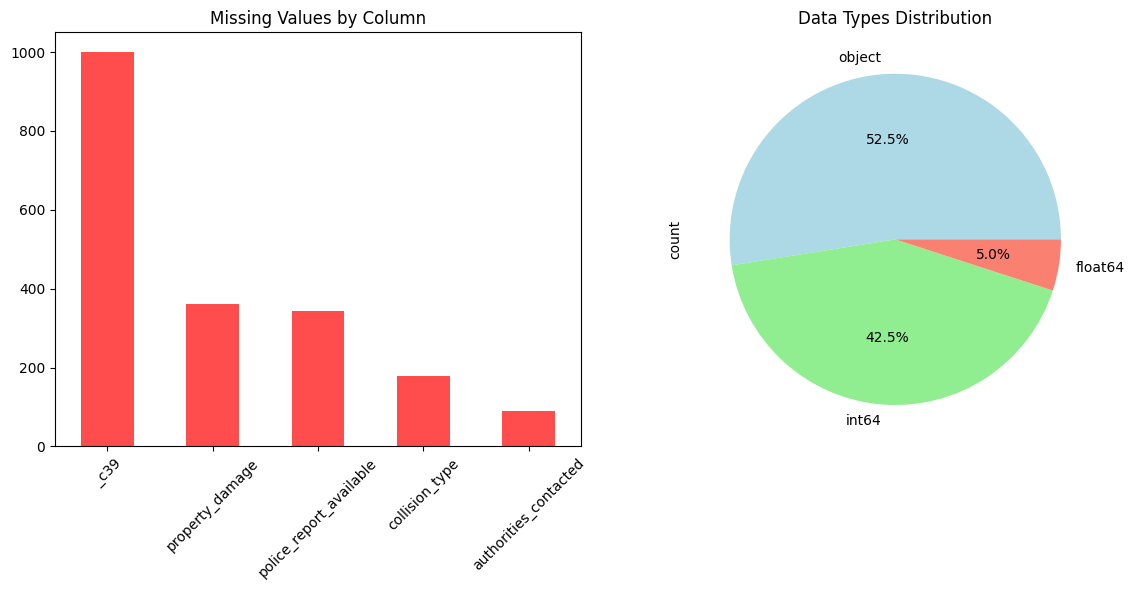

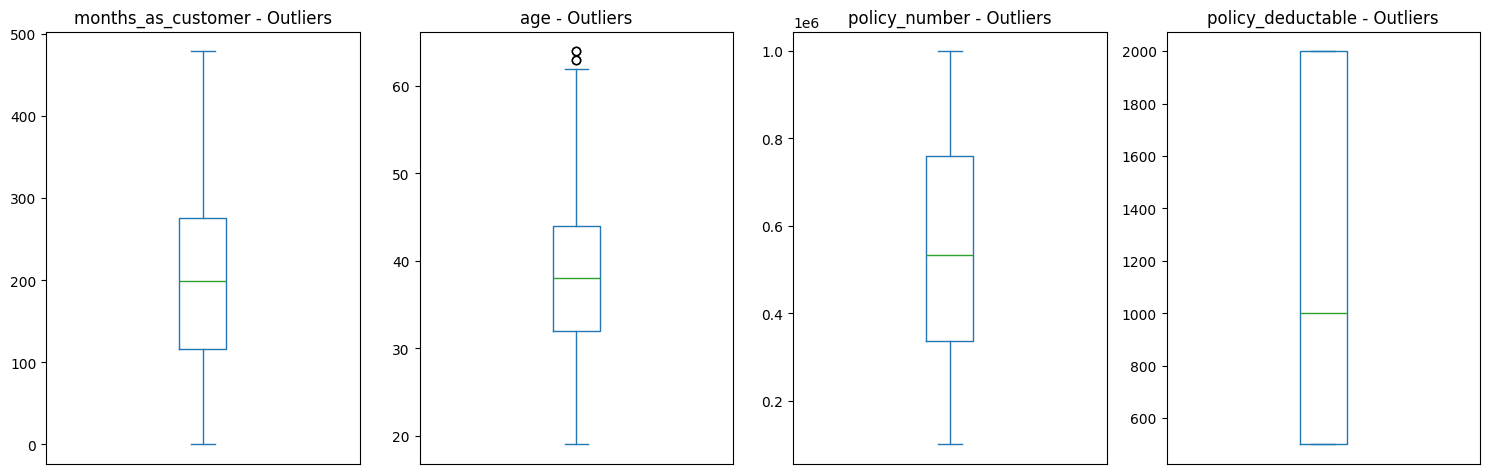

In [ ]:

def data_quality_report(data_claims):
    print("=" * 70)
    print("DATA QUALITY REPORT")
    print("=" * 70)

    # Basic info
    print(f"Dataset Shape: {data_claims.shape}")
    print(f"Missing Values: {data_claims.isna().sum().sum()}")
    print(f"Duplicate Rows: {data_claims.duplicated().sum()}")
    print(f"Duplicate Rows: {data_claims.duplicated().sum()}")
    print(f"Memory Usage: {data_claims.memory_usage(deep=True).sum() / 1024**2:.1f} MB\n")

    # Numerical variables quality

    numerical_cols = data_claims.select_dtypes(include=['int64', 'float64']).columns
    print("NUMERICAL VARIABLES QUALITY:")
    print("-" * 40)

    num_quality = []
    for col in numerical_cols:
        stats = {
            'Variable': col,
            'Missing': data_claims[col].isnull().sum(),
            'Missing %': (data_claims[col].isnull().sum() / len(data_claims)) * 100,
            'Zeros': (data_claims[col] == 0).sum(),
            'Zeros %': ((data_claims[col] == 0).sum() / len(data_claims)) * 100,
            'Mean': data_claims[col].mean(),
            'Std': data_claims[col].std(),
            'Outliers': detect_outliers_iqr(data_claims[col])
        }
        num_quality.append(stats)

    num_quality_df = pd.DataFrame(num_quality)
    print(num_quality_df.round(2).to_string(index=False))

    # Categorical variables quality
    categorical_cols = data_claims.select_dtypes(include=['object', 'category']).columns
    print(f"\nCATEGORICAL VARIABLES QUALITY:")
    print("-" * 40)

    cat_quality = []
    for col in categorical_cols:
        stats = {
            'Variable': col,
            'Missing': data_claims[col].isnull().sum(),
            'Missing %': (data_claims[col].isnull().sum() / len(data_claims)) * 100,
            'Unique': data_claims[col].nunique(),
            'Most Frequent': data_claims[col].mode().iloc[0] if not data_claims[col].mode().empty else 'N/A',
            'Freq Count': data_claims[col].value_counts().iloc[0] if not data_claims[col].value_counts().empty else 0
        }
        cat_quality.append(stats)

    cat_quality_df = pd.DataFrame(cat_quality)
    print(cat_quality_df.to_string(index=False))

    return num_quality_df, cat_quality_df

def detect_outliers_iqr(series):
    """Detect outliers using IQR method"""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    return len(outliers)

def plot_data_quality(data_claims):
    """Visualize data quality issues"""

    # Missing values visualization
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    missing_data = data_claims.isnull().sum().sort_values(ascending=False)
    missing_data = missing_data[missing_data > 0]
    if len(missing_data) > 0:
        missing_data.plot(kind='bar', color='red', alpha=0.7)
        plt.title('Missing Values by Column')
        plt.xticks(rotation=45)
    else:
        plt.text(0.5, 0.5, 'No Missing Values', ha='center', va='center', transform=plt.gca().transAxes)
        plt.title('Missing Values - None Found')

    # Data types distribution
    plt.subplot(1, 2, 2)
    dtype_counts = data_claims.dtypes.value_counts()
    dtype_counts.plot(kind='pie', autopct='%1.1f%%', colors=['lightblue', 'lightgreen', 'salmon'])
    plt.title('Data Types Distribution')

    plt.tight_layout()
    plt.show()

    # Numerical variables outliers
    numerical_cols = data_claims.select_dtypes(include=['int64', 'float64']).columns
    if len(numerical_cols) > 0:
        plt.figure(figsize=(15, 5))
        for i, col in enumerate(numerical_cols[:4]):  # Show first 4 numerical columns
            plt.subplot(1, 4, i+1)
            data_claims[col].plot(kind='box')
            plt.title(f'{col} - Outliers')
            plt.xticks([])
        plt.tight_layout()
        plt.show()

# Generate data quality report
num_quality, cat_quality = data_quality_report(data_claims)

# Visualize data quality
plot_data_quality(data_claims)


This visualization shows that property_damage, police_report_available, and collision_type have missing values, while _c39 is entirely null. The pie chart indicates a higher proportion of categorical variables, confirming the dataset needs encoding before modeling.

In [ ]:
# Extract key categorical variables
selected_cat_vars = ["property_damage", "police_report_available", "collision_type", "authorities_contacted", "incident_type", "fraud_reported"]

# Create ordered DataFrame
cat_quality_ordered = pd.DataFrame()
for var in selected_cat_vars:
    if var in cat_quality['Variable'].values:
        row = cat_quality[cat_quality['Variable'] == var]
        cat_quality_ordered = pd.concat([cat_quality_ordered, row])

print("SELECTED CATEGORICAL VARIABLES (ORDERED):")
print("-" * 55)
print(cat_quality_ordered.to_string(index=False))

SELECTED CATEGORICAL VARIABLES (ORDERED):
-------------------------------------------------------
               Variable  Missing  Missing %  Unique           Most Frequent  Freq Count
        property_damage      360       36.0       2                      NO         338
police_report_available      343       34.3       2                      NO         343
         collision_type      178       17.8       3          Rear Collision         292
  authorities_contacted       91        9.1       4                  Police         292
          incident_type        0        0.0       4 Multi-vehicle Collision         419
         fraud_reported        0        0.0       2                       N         753


In [ ]:
#Extract key numerical variables

selected_num_vars = ["policy_annual_premium", "total_claim_amount", "umbrella_limit", "injury_claim", "property_claim", "vehicle_claim"]

# Method 2: Custom summary statistics
print("SUMMARY STATISTICS:")
print("=" * 50)

detailed_stats = []
for col in selected_num_vars:
    stats = {
        'Variable': col,
        'Count': data_claims[col].count(),
        'Mean': data_claims[col].mean(),
        'Std': data_claims[col].std(),
        'Min': data_claims[col].min(),
        '25%': data_claims[col].quantile(0.25),
        'Median': data_claims[col].median(),
        '75%': data_claims[col].quantile(0.75),
        'Max': data_claims[col].max(),
    }
    detailed_stats.append(stats)

detailed_df = pd.DataFrame(detailed_stats)
pd.set_option('display.float_format', '{:,.2f}'.format)
s=print(detailed_df.to_string(index=False))
s

SUMMARY STATISTICS:
             Variable  Count         Mean          Std           Min       25%    Median       75%           Max
policy_annual_premium   1000     1,256.41       244.17        433.33  1,089.61  1,257.20  1,415.70      2,047.59
   total_claim_amount   1000    52,761.94    26,401.53        100.00 41,812.50 58,055.00 70,592.50    114,920.00
       umbrella_limit   1000 1,101,000.00 2,297,406.60 -1,000,000.00      0.00      0.00      0.00 10,000,000.00
         injury_claim   1000     7,433.42     4,880.95          0.00  4,295.00  6,775.00 11,305.00     21,450.00
       property_claim   1000     7,399.57     4,824.73          0.00  4,445.00  6,750.00 10,885.00     23,670.00
        vehicle_claim   1000    37,928.95    18,886.25         70.00 30,292.50 42,100.00 50,822.50     79,560.00


**Missing Value Summery**

In [ ]:
#Missing Value Summery
missing_report = data_claims.isnull().sum().reset_index()
missing_report.columns = ['column', 'missing_count']
missing_report['missing_%'] = round(missing_report['missing_count'] / len(data_claims) * 100, 2)
print("\nMissing Values Summary:")
print(missing_report[missing_report['missing_count'] > 0])




Missing Values Summary:
                     column  missing_count  missing_%
19           collision_type            178      17.80
21    authorities_contacted             91       9.10
27          property_damage            360      36.00
30  police_report_available            343      34.30
39                     _c39           1000     100.00


**FILLING GAPS AND DROPPING REDUNDANT COLUMN**

In [ ]:
#fill categorical columns with mode
cat_cols=data_claims.select_dtypes(include='object').columns
for col in cat_cols:
  data_claims[col].fillna(data_claims[col].mode()[0],inplace=True)

Missing values in the three identified categorical columns (collision_type, property_damage, police_report_available) are imputed using the mode (most frequent value).

In [ ]:
#Fixing data type of date
data_claims['policy_bind_date']=pd.to_datetime(data_claims['policy_bind_date'])
data_claims['incident_date']=pd.to_datetime(data_claims['incident_date'])

In [ ]:
#drop _c39 column as it has 1000 null values
data_claims.drop('_c39',axis=1,inplace=True)

This column contains 100% missing values (NaN) and is irrelevant to the analysis.

In [ ]:
#also we can drop policy_number, insured_zip as it is not meaningful for our analysis
data_claims.drop(['policy_number','insured_zip'],axis=1,inplace=True)

In [ ]:
#verify the columns for null values again
data_claims.isnull().sum()

,0
months_as_customer,0
age,0
policy_bind_date,0
policy_state,0
policy_csl,0
policy_deductable,0
policy_annual_premium,0
umbrella_limit,0
insured_sex,0
insured_education_level,0


Our dataset is now clean with no null values

# **FEATURE CONSTRUCTION**

In [ ]:
# Create new feature policy age and drop policy bind date
data_claims['policy_age'] = pd.to_datetime("today") - data_claims['policy_bind_date']
data_claims['policy_age'] = data_claims['policy_age'].dt.days
data_claims.drop('policy_bind_date', axis=1, inplace=True)

In [ ]:
#create age buckets
bins=[18,30,40,50,60,70,80,90,100]
labels=['18-29','30-39','40-49','50-59','60-69','70-79','80-89','90-100']
data_claims['age_bucket']=pd.cut(data_claims['age'],bins=bins,labels=labels)
data_claims.drop(columns=['age'], inplace=True)
data_claims['age_bucket'].value_counts()


,count
age_bucket,
30-39,396
40-49,293
18-29,197
50-59,96
60-69,18
70-79,0
80-89,0
90-100,0


A new feature, age_bucket, is created to group ages into categorical ranges. This reduces feature complexity and captures non-linear age effects.

**OUTLIER DETECTION**

In [ ]:
#select color palette
palette = {0: 'blue', 1: 'orange'}

In [ ]:
# Outlier detection for numeric columns using IQR
numeric_cols = data_claims.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_cols:
    Q1 = data_claims[col].quantile(0.25)
    Q3 = data_claims[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data_claims[(data_claims[col] < lower_bound) | (data_claims[col] > upper_bound)]
    print(f"Outliers in {col}:")
    print(outliers)
    print("\n")


Outliers in months_as_customer:
Empty DataFrame
Columns: [months_as_customer, policy_state, policy_csl, policy_deductable, policy_annual_premium, umbrella_limit, insured_sex, insured_education_level, insured_occupation, insured_hobbies, insured_relationship, capital-gains, capital-loss, incident_date, incident_type, collision_type, incident_severity, authorities_contacted, incident_state, incident_city, incident_location, incident_hour_of_the_day, number_of_vehicles_involved, property_damage, bodily_injuries, witnesses, police_report_available, total_claim_amount, injury_claim, property_claim, vehicle_claim, auto_make, auto_model, auto_year, fraud_reported, policy_age, age_bucket]
Index: []

[0 rows x 37 columns]


Outliers in policy_deductable:
Empty DataFrame
Columns: [months_as_customer, policy_state, policy_csl, policy_deductable, policy_annual_premium, umbrella_limit, insured_sex, insured_education_level, insured_occupation, insured_hobbies, insured_relationship, capital-gains, ca

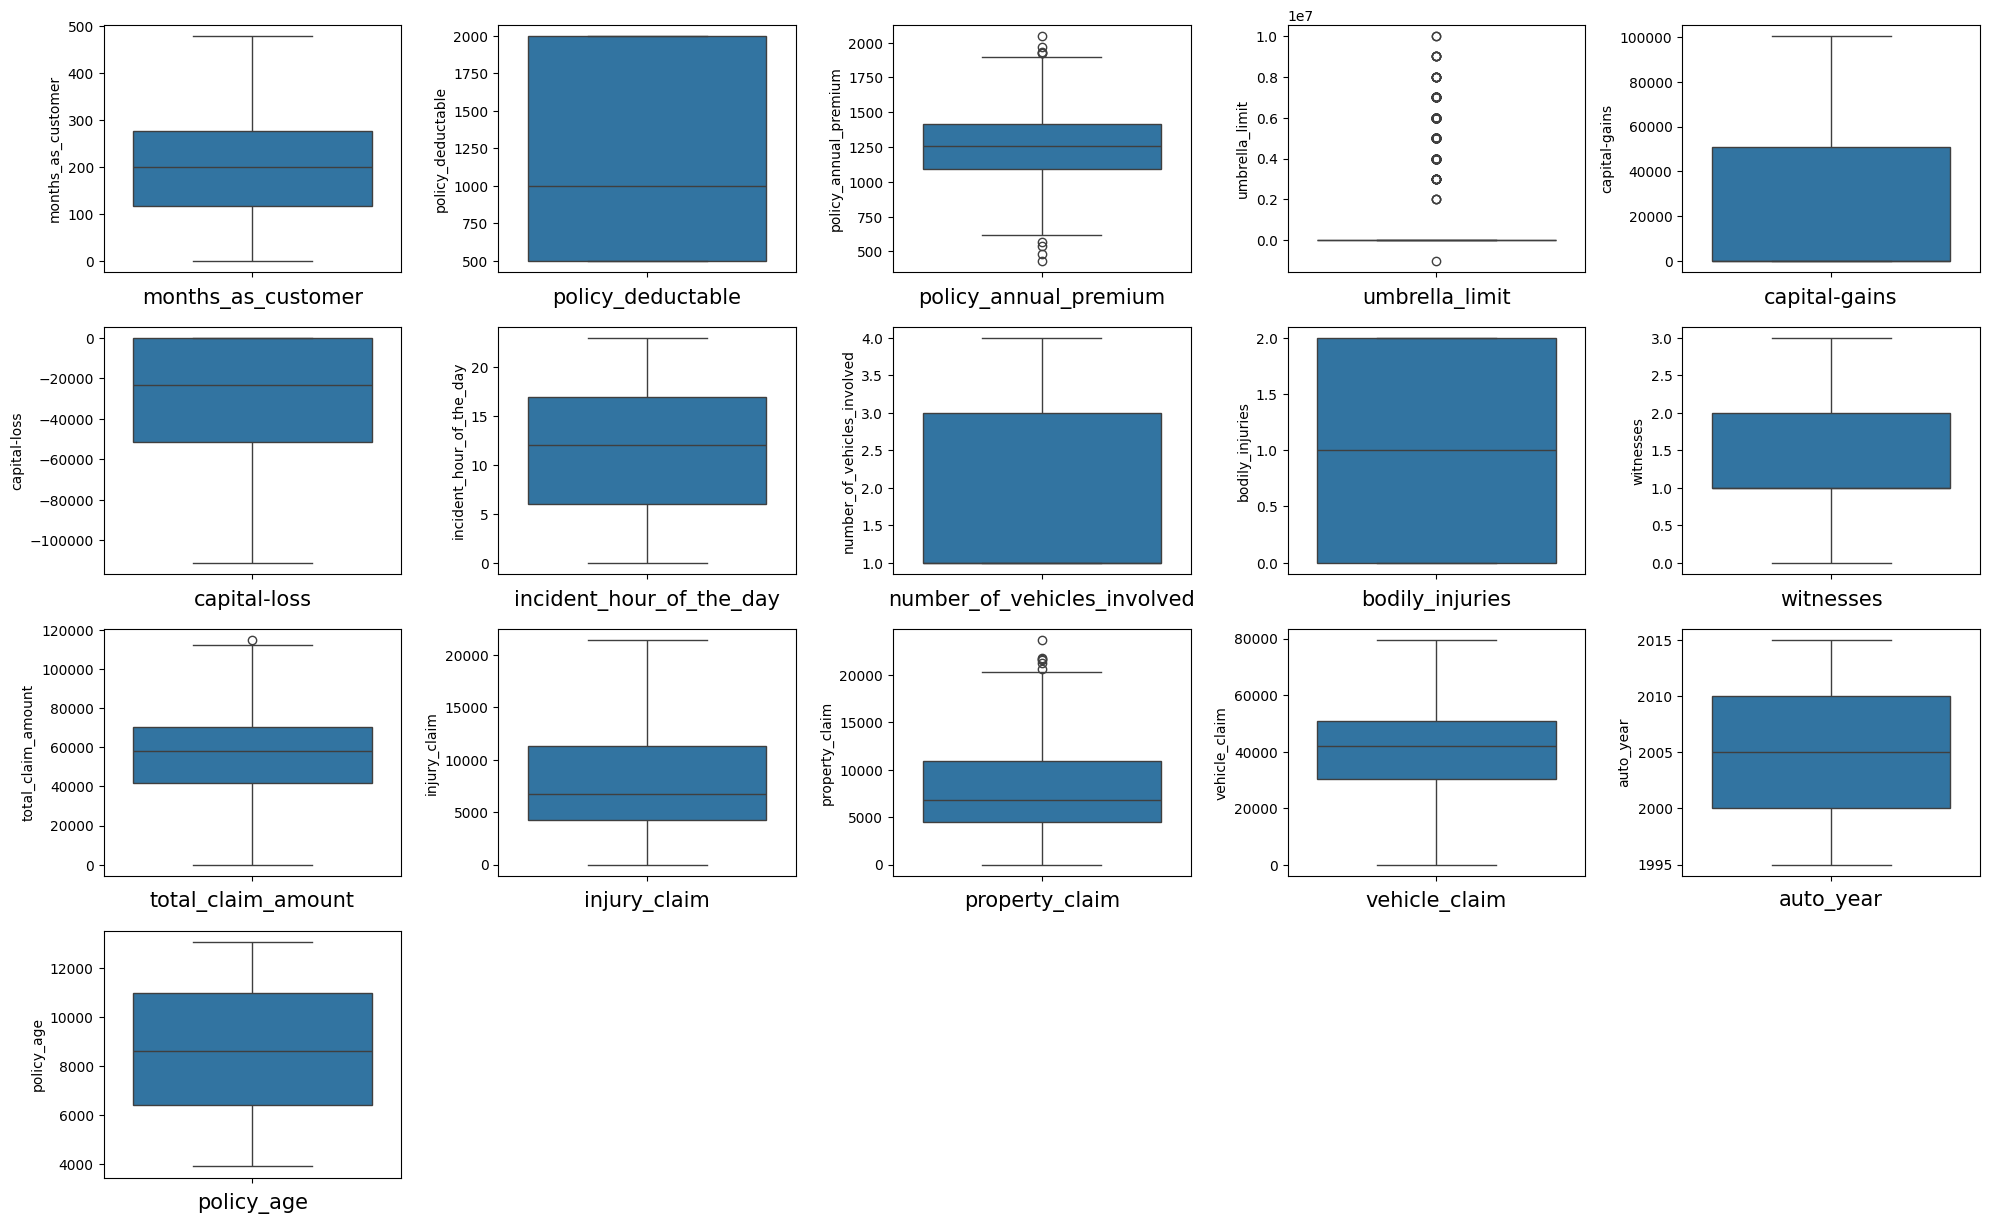

In [ ]:
#Select only int64 fields and float
numeric_fields=data_claims.select_dtypes(include=['int64','float'])


plt.figure(figsize = (20, 15))
plotnumber = 1

for col in numeric_fields.columns:
    if plotnumber <= 24:
        ax = plt.subplot(5, 5, plotnumber)
        sns.boxplot(numeric_fields[col])
        plt.xlabel(col, fontsize = 15)

    plotnumber += 1

plt.tight_layout()
plt.show()


The boxplots highlight extreme values in features like umbrella_limit, total_claim_amount, and policy_annual_premium. These outliers likely represent rare, high-value claims that could be associated with fraudulent activities.

#**DATA TRANSFORMATION (ENCODING)**

In [ ]:
# Encode Target Variable: 'Y' (Fraud) -> 1, 'N' (Not Fraud) -> 0
data_claims['fraud_reported'] = data_claims['fraud_reported'].apply(lambda x: 1 if x == 'Y' else 0)
#Converts the categorical target variable fraud_reported to a binary numeric format: Non-Fraud (0) and Fraud (1), which is mandatory for classification algorithms.

data_claims.dtypes.value_counts()

,count
object,18
int64,16
float64,1
datetime64[ns],1
category,1


# **EXPLORATORY DATA ANALYSIS (EDA)**

## **UNIVARIATE ANALYSIS**

**Distribution of Fraudulent Claims**

**Class Imbalance**

fraud_reported
0   0.75
1   0.25
Name: proportion, dtype: float64


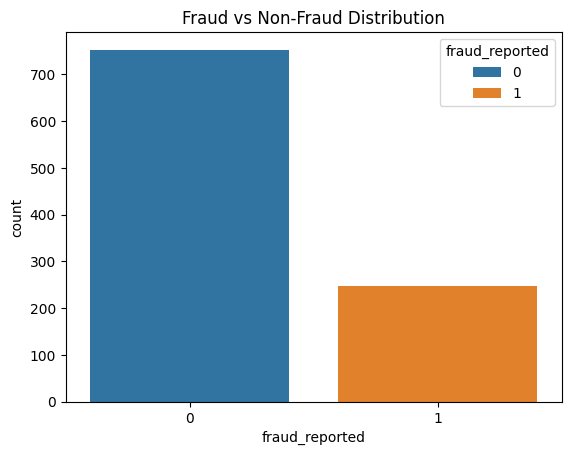

In [ ]:
# Distribution of fraud
fraud_counts = data_claims['fraud_reported'].value_counts(normalize=True)
print(fraud_counts)
sns.countplot(x='fraud_reported', data=data_claims,hue='fraud_reported')
plt.title("Fraud vs Non-Fraud Distribution")
plt.show()

The bar plot reveals severe class imbalance with 75% legitimate claims and only 25% fraudulent ones. This imbalance poses a significant challenge for modeling as algorithms may become biased toward predicting the majority class. The dataset contains 753 non-fraudulent claims versus 247 fraudulent claims, indicating that fraud detection is inherently a rare event problem that requires specialized handling techniques.

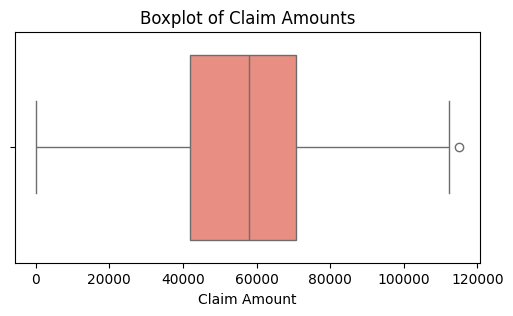

In [ ]:
plt.figure(figsize=(6,3))
sns.boxplot(x=data_claims['total_claim_amount'], color="salmon")
plt.title("Boxplot of Claim Amounts")
plt.xlabel("Claim Amount")
plt.show()


The boxplot shows right-skewed distribution with several extreme values in total claim amounts. The presence of numerous outliers suggests that some claims are substantially larger than typical cases. These extreme values could represent either legitimate high-severity incidents or potentially inflated fraudulent claims, making this variable particularly important for fraud detection.

**Histogram of Numeriv variables**

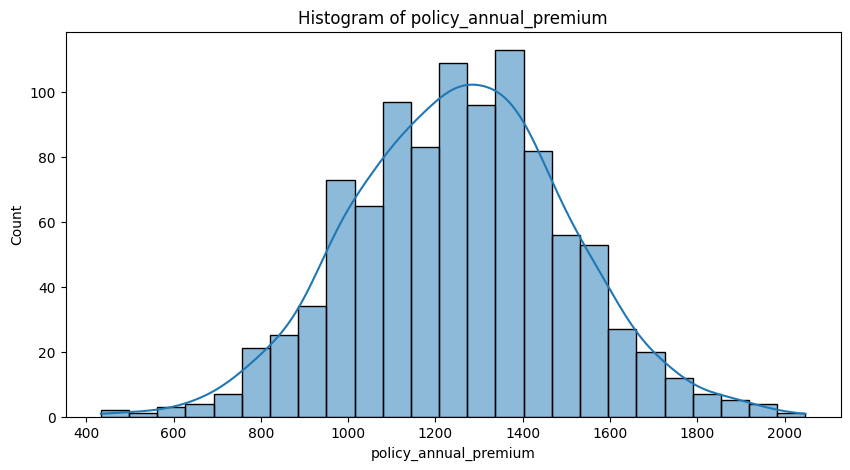

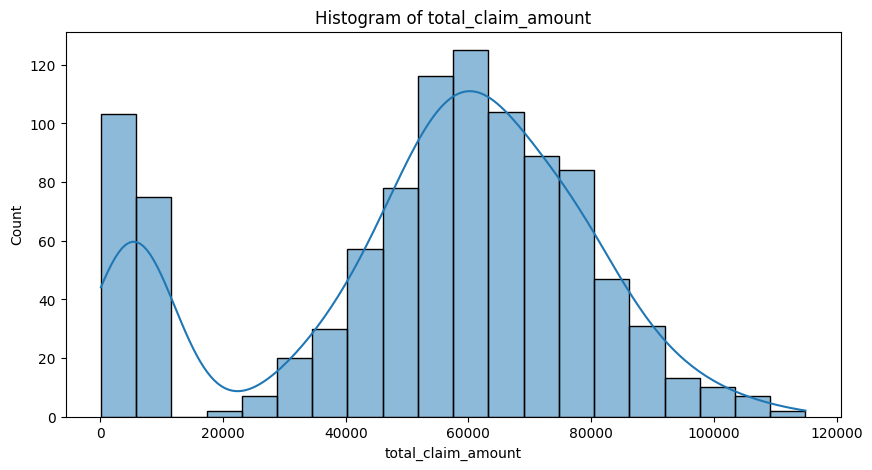

In [ ]:
numerical_cols_uni = ['policy_annual_premium', 'total_claim_amount']
for i, col in enumerate(numerical_cols_uni):
    plt.figure(figsize=(10, 5))
    sns.histplot(data_claims[col], kde=True)
    plt.title(f'Histogram of {col}')
    plt.show()

The distribution appears roughly normal with slight right skew, indicating most policies cluster around moderate premium values. There are fewer policies at both the low and high extremes, suggesting relatively standardized pricing. The absence of extreme outliers in premiums contrasts with the claim amount distribution, indicating different underlying patterns.

**KEY CATEGORICAL DISTRIBUTION**

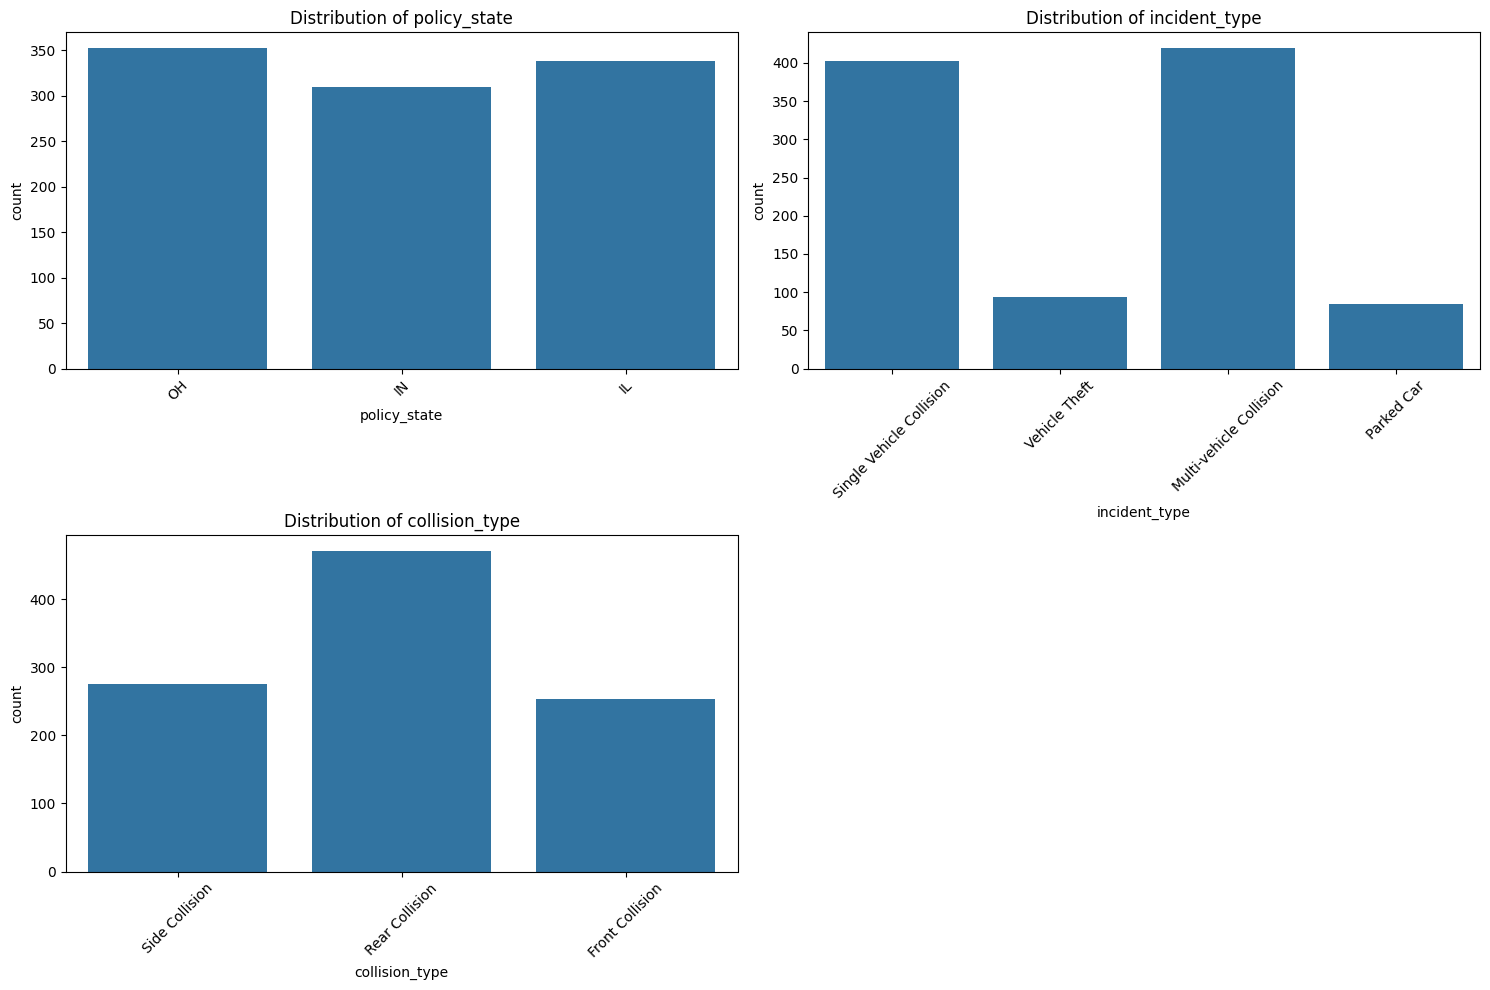

fraud_reported    0   1
policy_state           
IL              261  77
IN              231  79
OH              261  91
fraud_reported              0    1
incident_type                     
Multi-vehicle Collision   305  114
Parked Car                 76    8
Single Vehicle Collision  286  117
Vehicle Theft              86    8


In [ ]:
categorical_cols_uni = ['policy_state', 'incident_type', 'collision_type']
i = 1
plt.figure(figsize=(15, 10))
for col in categorical_cols_uni:
    plt.subplot(2,2,i)
    sns.countplot(x=col, data=data_claims)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    i += 1
    plt.tight_layout()
plt.show()



#Crosstab for counts
print(pd.crosstab(data_claims['policy_state'], data_claims['fraud_reported']))

print(pd.crosstab(data_claims['incident_type'], data_claims['fraud_reported']))


Policy states (OH, IN, IL) show relatively even distribution, minimizing regional bias. Multi-vehicle collisions dominate incident types, while rear collisions are most common among collision types. The consistent patterns across categories suggest the dataset represents diverse but balanced scenarios across different claim characteristics.



# **BIVARIATE ANALYSIS**


##**Key categorical variables vs fraud**




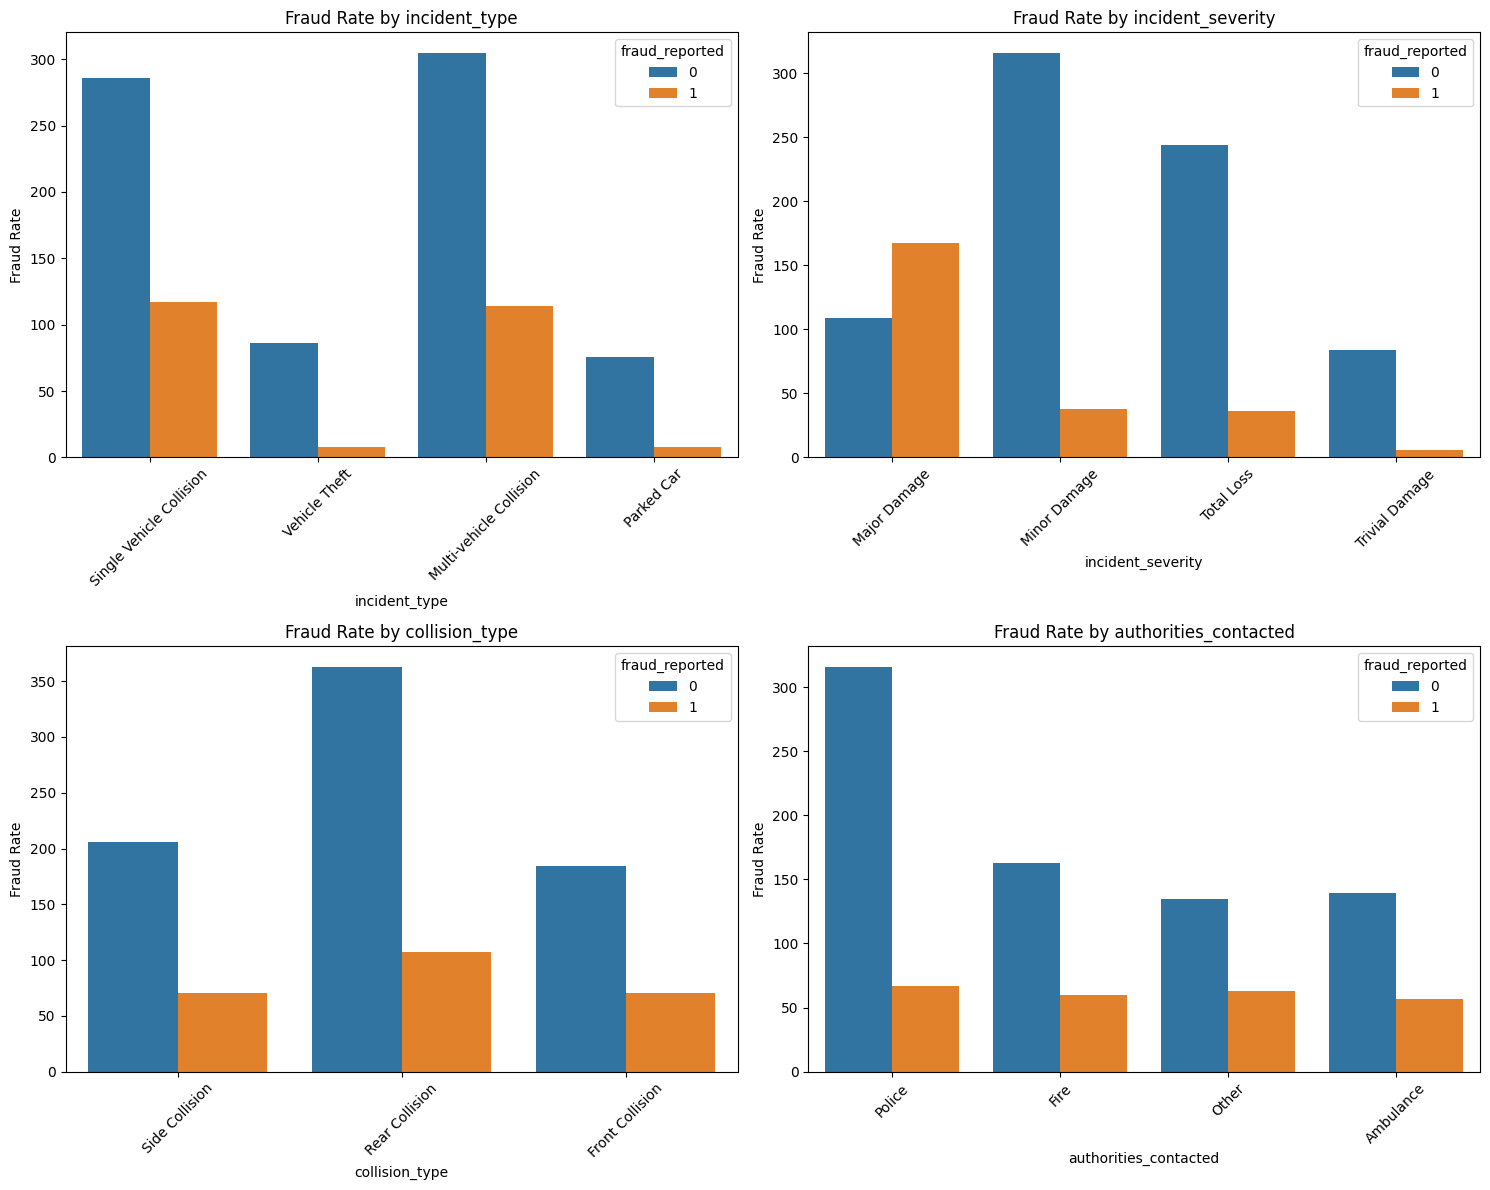

fraud_reported              0    1
incident_type                     
Multi-vehicle Collision   305  114
Parked Car                 76    8
Single Vehicle Collision  286  117
Vehicle Theft              86    8
fraud_reported       0    1
incident_severity          
Major Damage       109  167
Minor Damage       316   38
Total Loss         244   36
Trivial Damage      84    6
fraud_reported     0    1
collision_type           
Front Collision  184   70
Rear Collision   363  107
Side Collision   206   70
fraud_reported           0   1
authorities_contacted         
Ambulance              139  57
Fire                   163  60
Other                  135  63
Police                 316  67


In [ ]:
# Key categorical variables vs fraud
key_categorical = ['incident_type', 'incident_severity', 'collision_type', 'authorities_contacted']
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

for i, col in enumerate(key_categorical):

    sns.countplot(x=col, hue='fraud_reported', data=data_claims, ax=axes[i])
    axes[i].set_title(f'Fraud Rate by {col}')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
    axes[i].set_ylabel('Fraud Rate')
plt.tight_layout()
plt.show()

# Crosstab for counts
print(pd.crosstab(data_claims['incident_type'], data_claims['fraud_reported']))

print(pd.crosstab(data_claims['incident_severity'], data_claims['fraud_reported']))

print(pd.crosstab(data_claims['collision_type'], data_claims['fraud_reported']))

print(pd.crosstab(data_claims['authorities_contacted'], data_claims['fraud_reported']))


Major damage incidents show dramatically higher fraud rates compared to minor or trivial damage. Single and multi-vehicle collisions have similar fraud prevalence, while parked car and vehicle theft incidents show lower fraud rates. This indicates that fraudsters tend to target more severe, complex incidents where claim amounts are higher and investigation is more challenging.

##**Numerical variable vs Fraud**

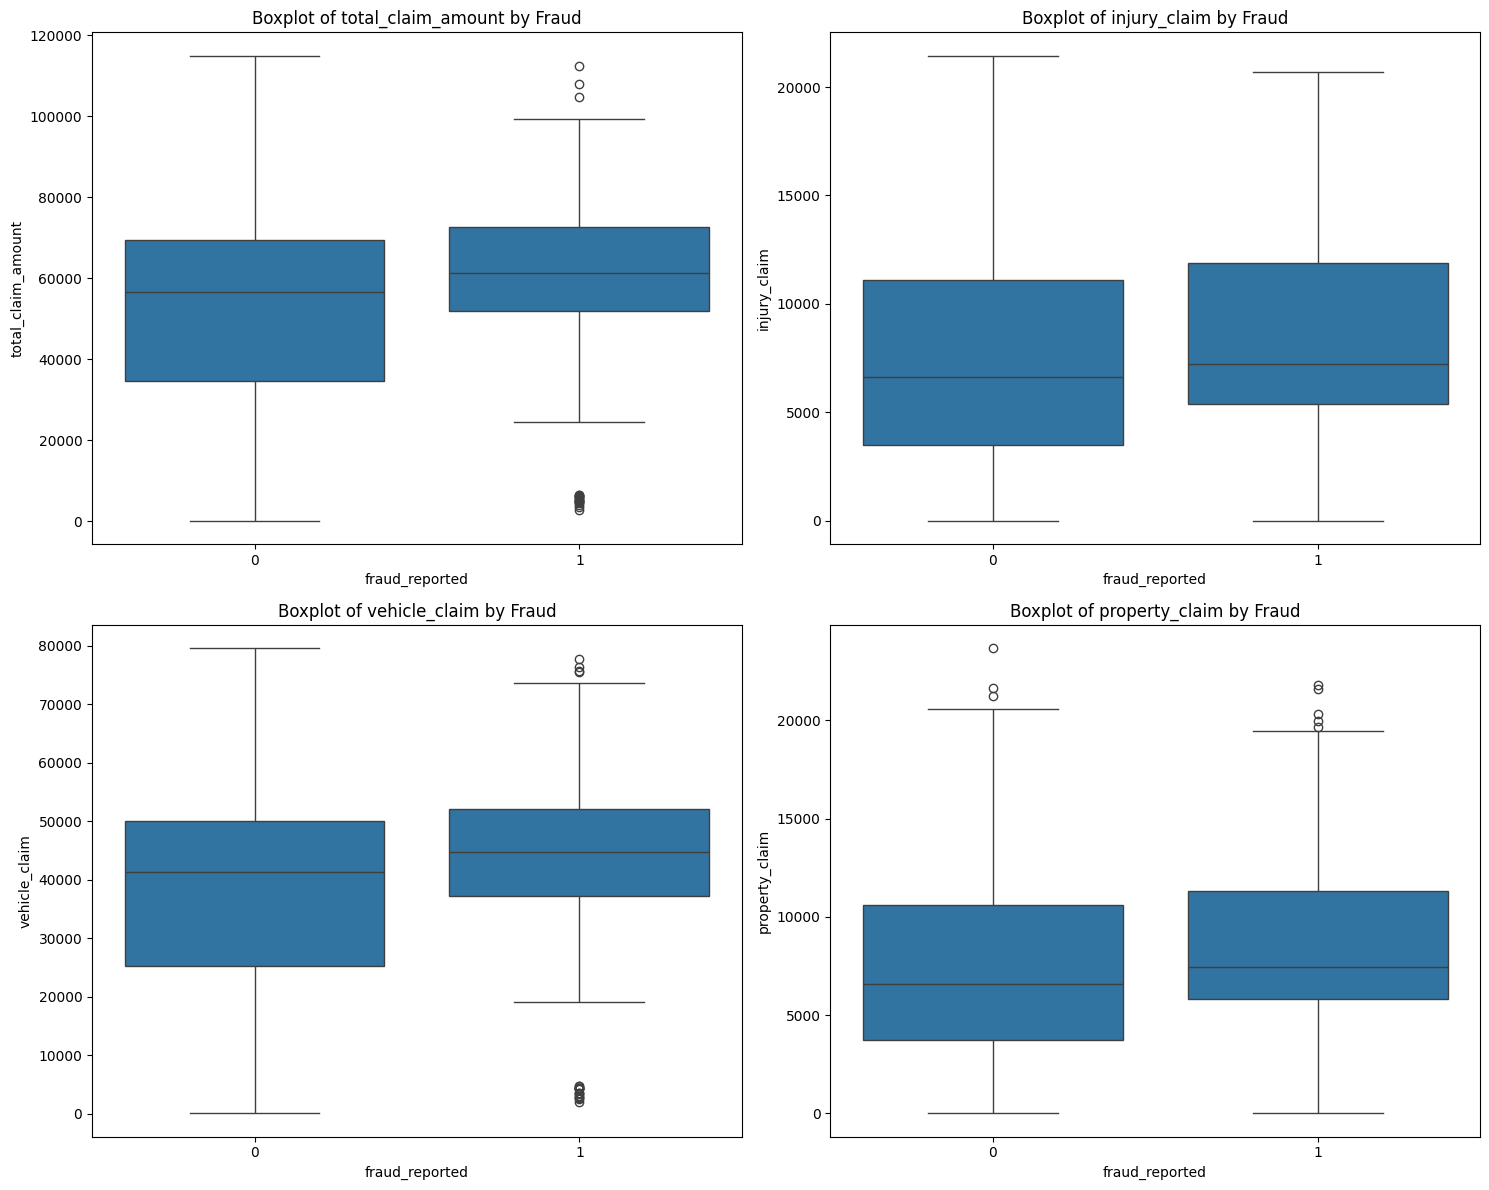

In [ ]:
#NUMERICAL DISTRIBUTION
#Numeric vs fraud: boxplots for a few numeric fields
numeric_cols_uni = ["total_claim_amount","injury_claim","vehicle_claim","property_claim"]
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

for i, col in enumerate(numeric_cols_uni):
    sns.boxplot(x='fraud_reported', y=col, data=data_claims, ax=axes[i])
    axes[i].set_title(f'Boxplot of {col} by Fraud')
    axes[i].set_ylabel(col)
plt.tight_layout()
plt.show()




Fraudulent claims consistently show higher median values across all claim types (total, injury, vehicle, property). The interquartile ranges for fraudulent claims are wider, indicating more variability in claim amounts. Non-fraudulent claims have tighter distributions with lower medians, suggesting more predictable, legitimate claim patterns.

**Different types of claim amount vs Incident Severity**

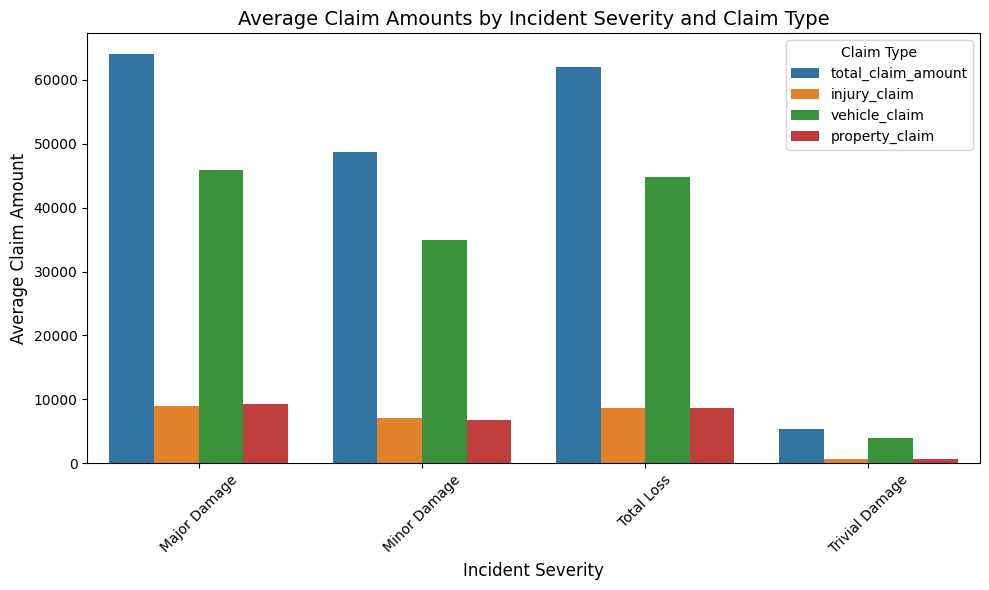

fraud_reported       0    1
incident_severity          
Major Damage       109  167
Minor Damage       316   38
Total Loss         244   36
Trivial Damage      84    6


In [ ]:
# Grouped Bar Plot of Claim Types vs Incident Severity
# Select relevant claim columns
claim_cols = ["total_claim_amount", "injury_claim", "vehicle_claim", "property_claim"]

# Ensure columns exist
claim_cols = [col for col in claim_cols if col in data_claims.columns]

# Melt data to long format for grouped plotting
df_melt = data_claims.melt(id_vars="incident_severity",value_vars=claim_cols,var_name="Claim_Type",value_name="Claim_Amount")

plt.figure(figsize=(10, 6))
sns.barplot(data=df_melt,x="incident_severity",y="Claim_Amount",hue="Claim_Type",estimator=np.mean,ci=None)

plt.title("Average Claim Amounts by Incident Severity and Claim Type", fontsize=14)
plt.xlabel("Incident Severity", fontsize=12)
plt.ylabel("Average Claim Amount", fontsize=12)
plt.legend(title="Claim Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(pd.crosstab(data_claims['incident_severity'], data_claims['fraud_reported']))





The grouped bar plot shows that average claim amounts increase sharply from “Minor Damage” to “Total Loss.” .Claim amounts increase substantially with incident severity, with "Total Loss" incidents generating the highest average costs. Vehicle claims constitute the largest portion across all severity levels. The progressive increase from minor to total loss incidents demonstrates logical cost escalation with damage severity.

**What is the relationship between incident types and severities by policy state?**

incident_severity                      Major Damage  Minor Damage  Total Loss  \
policy_state incident_type                                                      
IL           Multi-vehicle Collision             49            50          54   
             Parked Car                           0            10           0   
             Single Vehicle Collision            43            44          40   
             Vehicle Theft                        0            12           0   
IN           Multi-vehicle Collision             45            36          42   

incident_severity                      Trivial Damage  
policy_state incident_type                             
IL           Multi-vehicle Collision                0  
             Parked Car                            15  
             Single Vehicle Collision               0  
             Vehicle Theft                         21  
IN           Multi-vehicle Collision                0  


<Figure size 1000x1000 with 0 Axes>

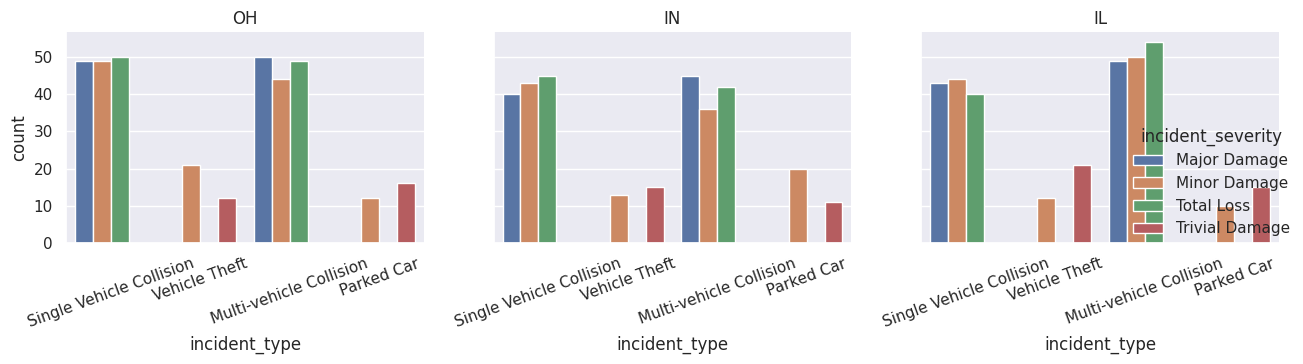

Computed crosstab and plotted incident_type by severity faceted by policy_state.


In [ ]:
#Incident types vs severities by policy state (crosstab + faceted countplot)

plt.figure(figsize=(10,10))

ct = pd.crosstab(index=[data_claims['policy_state'], data_claims['incident_type']], columns=data_claims['incident_severity'])
print(ct.head())

sns.set_theme()
g = sns.catplot(data=data_claims, x='incident_type', hue='incident_severity', col='policy_state', kind='count', col_wrap=3, height=3.8)
g.set_titles('{col_name}')
for ax in g.axes.flatten():
    for label in ax.get_xticklabels():
        label.set_rotation(20)
plt.tight_layout()
plt.show()

print('Computed crosstab and plotted incident_type by severity faceted by policy_state.')

Plots reveal that certain states (like IL and OH) have higher frequencies of major or total-loss incidents in multi-vehicle collisions. This may indicate region-specific risk or potential fraud hotspots.

#**Fraud reported by policy Features?**

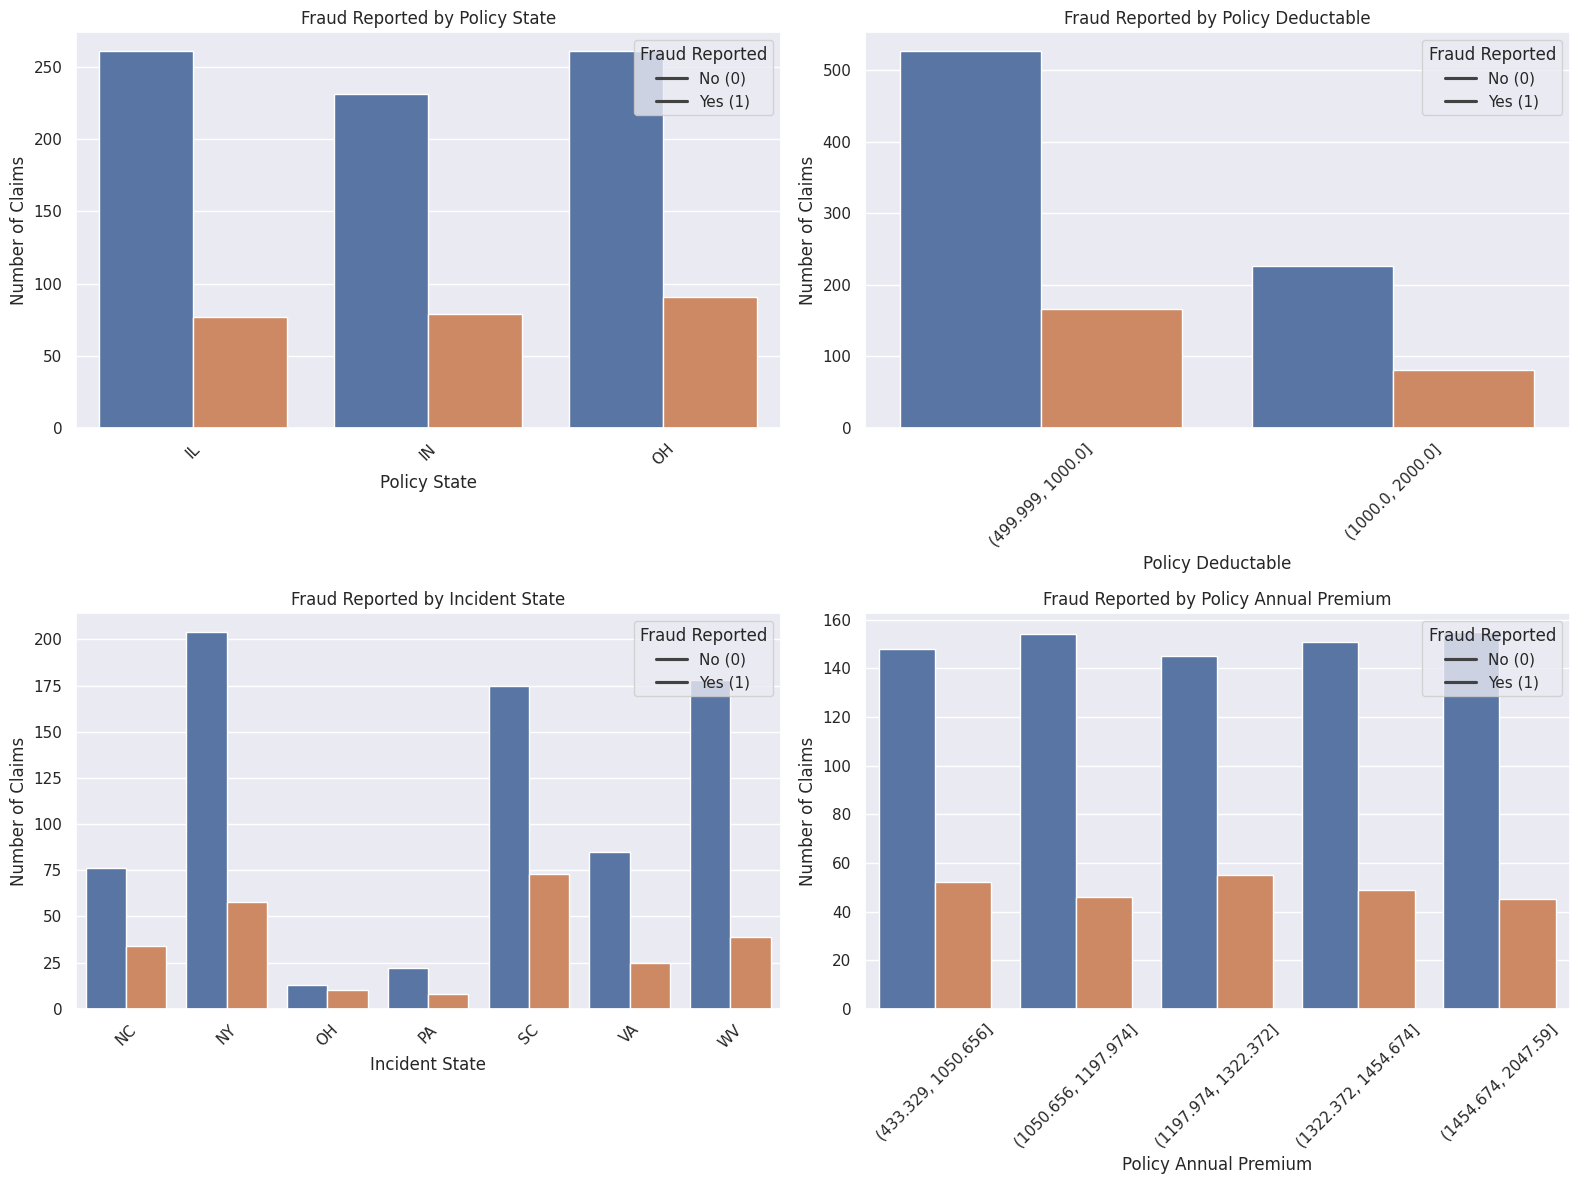

In [ ]:

policy_vars = ["policy_state", "policy_deductable", "incident_state", "policy_annual_premium"]

# Set up subplots (2 rows x 2 columns for 4 variables)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()  # flatten to 1D array for easy iteration

for i, var in enumerate(policy_vars):
    if var in data_claims.columns:
        ax = axes[i]

        # If numeric, bin it into 5 quantiles
        if pd.api.types.is_numeric_dtype(data_claims[var]):
            binned_var = f"{var}_bin"
            data_claims[binned_var] = pd.qcut(data_claims[var], q=5, duplicates='drop')
            plot_var = binned_var
        else:
            plot_var = var

        # Count of fraud_reported by category/bin
        count_df = data_claims.groupby([plot_var, 'fraud_reported']).size().reset_index(name='count')

        sns.barplot(
            data=count_df,
            x=plot_var,
            y='count',
            hue='fraud_reported',
            ax=ax
        )

        ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
        ax.set_xlabel(var.replace('_',' ').title())
        ax.set_ylabel("Number of Claims")
        ax.set_title(f"Fraud Reported by {var.replace('_',' ').title()}")
        ax.legend(title='Fraud Reported', labels=['No (0)','Yes (1)'])

plt.tight_layout()
plt.show()


Fraud occurrence varies with factors like policy deductibles and annual premiums. Lower deductibles and higher premiums tend to correlate with higher fraud frequency—possibly because high coverage value attracts fraud attempts.

#**Customer Attributes affect fraud?**

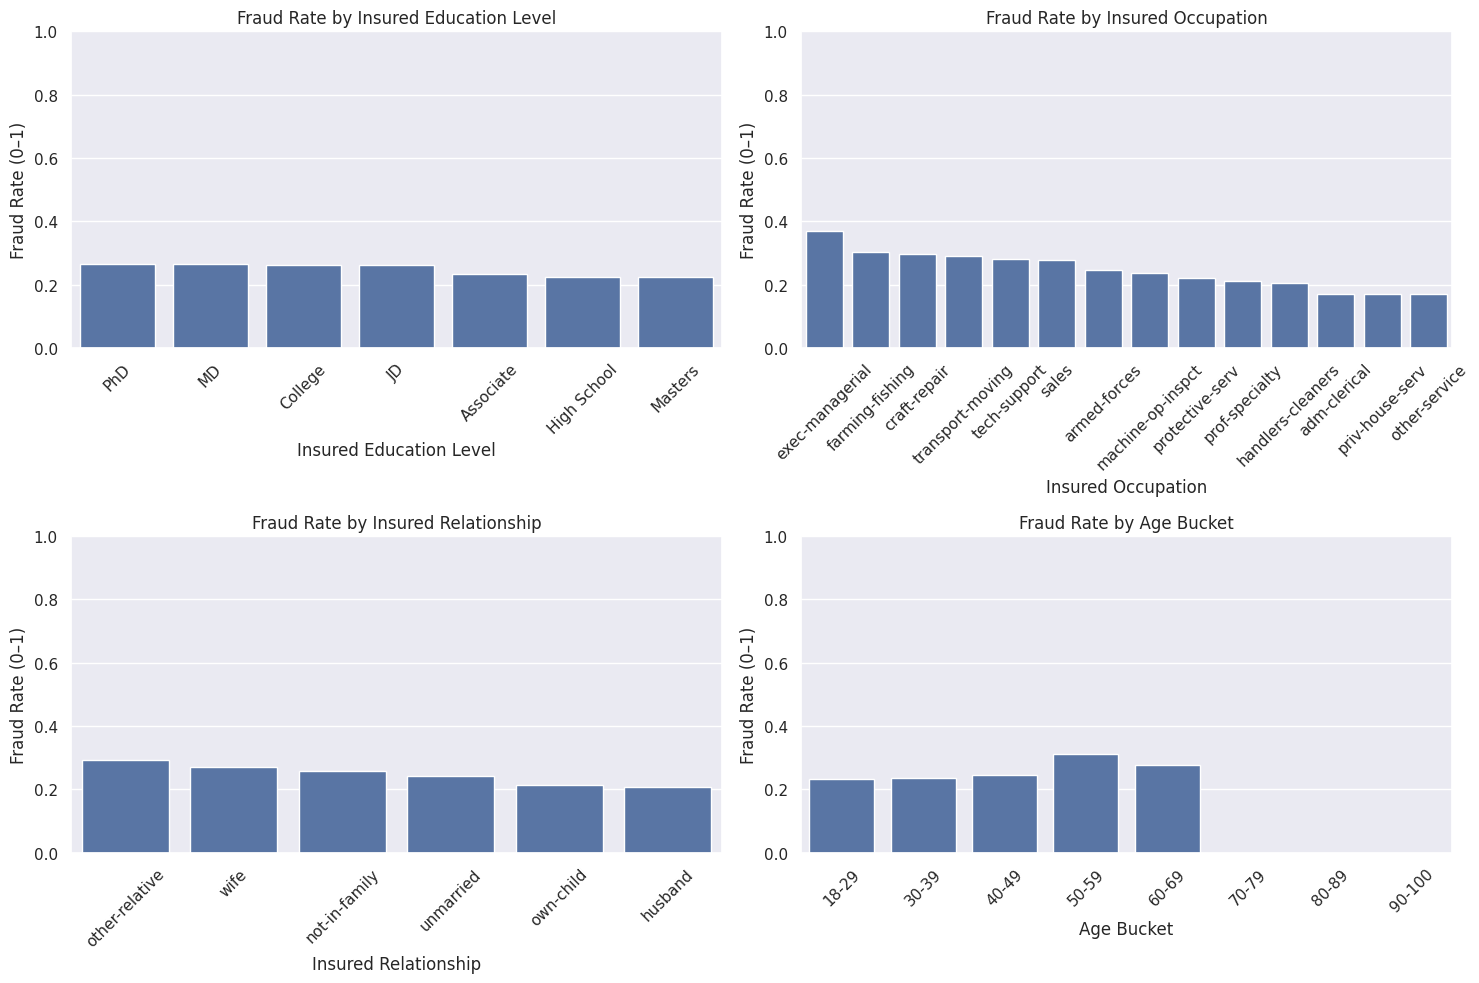

fraud_reported       0   1
insured_occupation        
adm-clerical        54  11
armed-forces        52  17
craft-repair        52  22
exec-managerial     48  28
farming-fishing     37  16
handlers-cleaners   43  11
machine-op-inspct   71  22
other-service       59  12
priv-house-serv     59  12
prof-specialty      67  18
protective-serv     49  14
sales               55  21
tech-support        56  22
transport-moving    51  21
fraud_reported          0   1
insured_relationship         
husband               135  35
not-in-family         129  45
other-relative        125  52
own-child             144  39
unmarried             107  34
wife                  113  42
fraud_reported             0   1
insured_education_level         
Associate                111  34
College                   90  32
High School              124  36
JD                       119  42
MD                       106  38
Masters                  111  32
PhD                       92  33
fraud_reported    0   1
age_buc

In [ ]:

# Fraud Rate by Customer Attributes (Grouped Subplots)

cust_vars = ["insured_education_level", "insured_occupation", "insured_relationship", "age_bucket"]

def fraud_rate_by(df, var):
    """Compute fraud rate (mean of fraud_reported) for each category of var."""
    rate = (
        df.groupby(var)['fraud_reported']
        .mean()
        .reset_index()
        .rename(columns={'fraud_reported': 'fraud_rate'})
    )
    return rate.sort_values('fraud_rate', ascending=False)

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for i, var in enumerate(cust_vars):
    if var in data_claims.columns:
        rate = fraud_rate_by(data_claims, var)
        sns.barplot(data=rate, x=var, y="fraud_rate", ax=axes[i])
        axes[i].set_title(f"Fraud Rate by {var.replace('_',' ').title()}")
        axes[i].set_xlabel(var.replace('_',' ').title())
        axes[i].set_ylabel("Fraud Rate (0–1)")
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].set_ylim(0, 1)
    else:
        axes[i].axis("off")  # in case column is missing

plt.tight_layout()
plt.show()

print(pd.crosstab(data_claims['insured_occupation'], data_claims['fraud_reported']))
print(pd.crosstab(data_claims['insured_relationship'], data_claims['fraud_reported']))
print(pd.crosstab(data_claims['insured_education_level'], data_claims['fraud_reported']))
print(pd.crosstab(data_claims['age_bucket'], data_claims['fraud_reported']))



Bar plots show that fraud rates differ by occupation, education, relationship status, and age group. Professions like executive and protective services and middle-aged policyholders (30–49) exhibit slightly higher fraud tendencies.

# **Vehicle type vs fraud?**

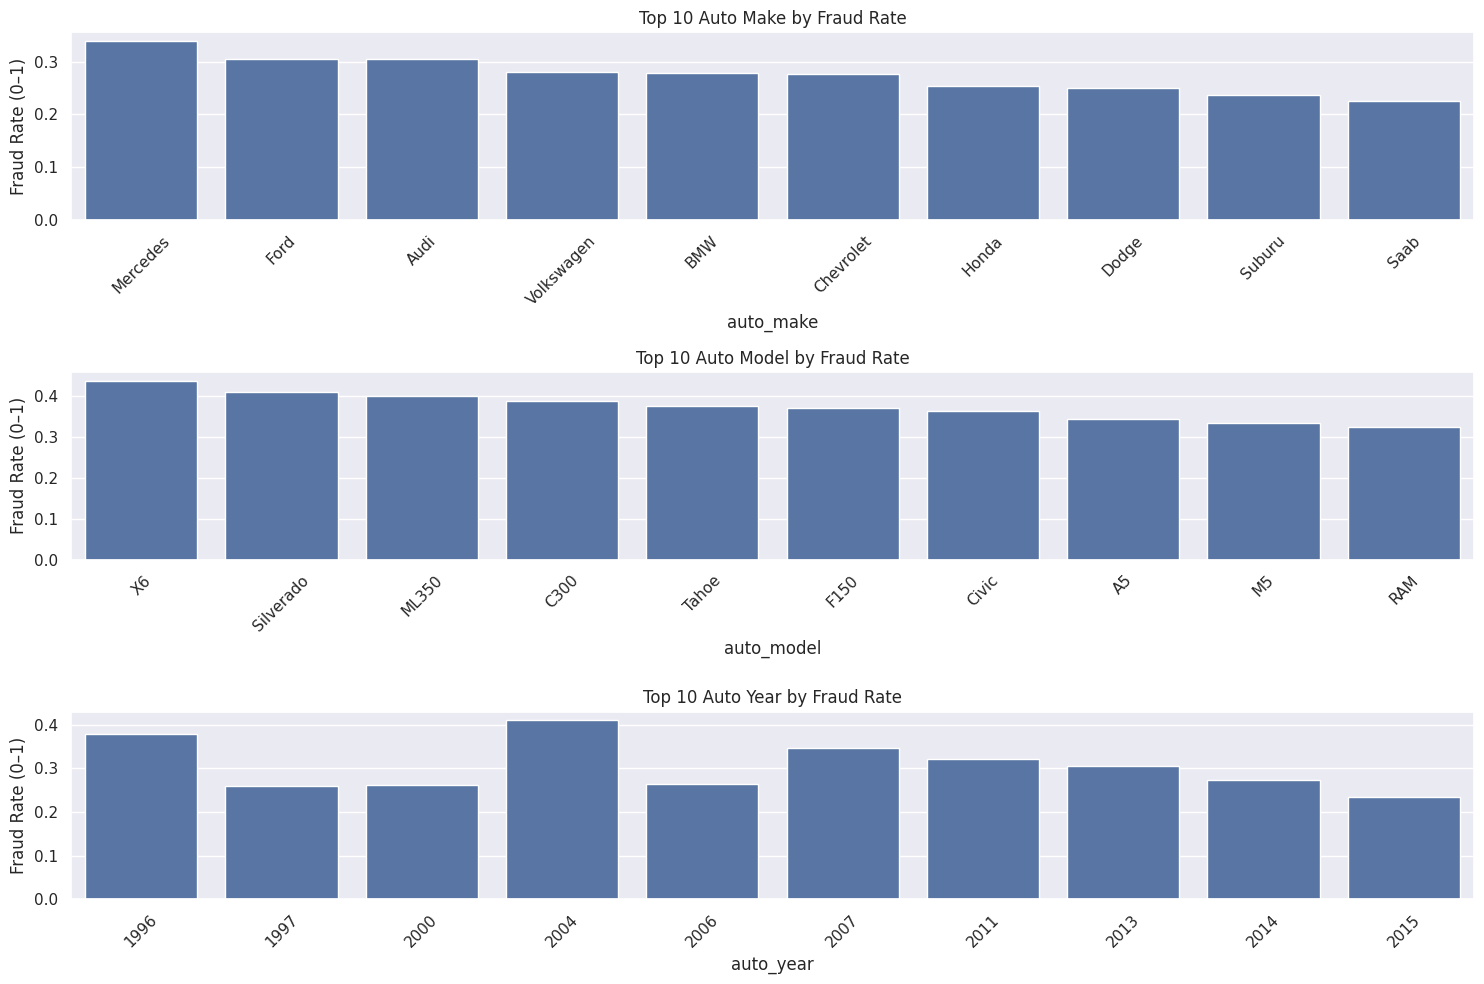

In [ ]:
veh_vars = ["auto_make", "auto_model", "auto_year"]
fig, axes = plt.subplots(3, 1, figsize=(15, 10))
axes = axes.ravel()
i = 0

for var in veh_vars:
  if var in data_claims.columns:
    rate = fraud_rate_by(data_claims, var)
    sns.barplot(data=rate.head(10), x=var, y="fraud_rate",ax=axes[i])
    axes[i].set_title(f"Top 10 {var.replace('_',' ').title()} by Fraud Rate")
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
    axes[i].set_ylabel("Fraud Rate (0–1)")
    i += 1
    plt.tight_layout()
plt.show()






Plots of auto_make and auto_model show that certain car brands (e.g., Dodge, Mercedes) have higher fraud rates. This could reflect differences in repair costs or popularity in fraudulent claim cases.

#**Fraud rate by reporting behaviour**

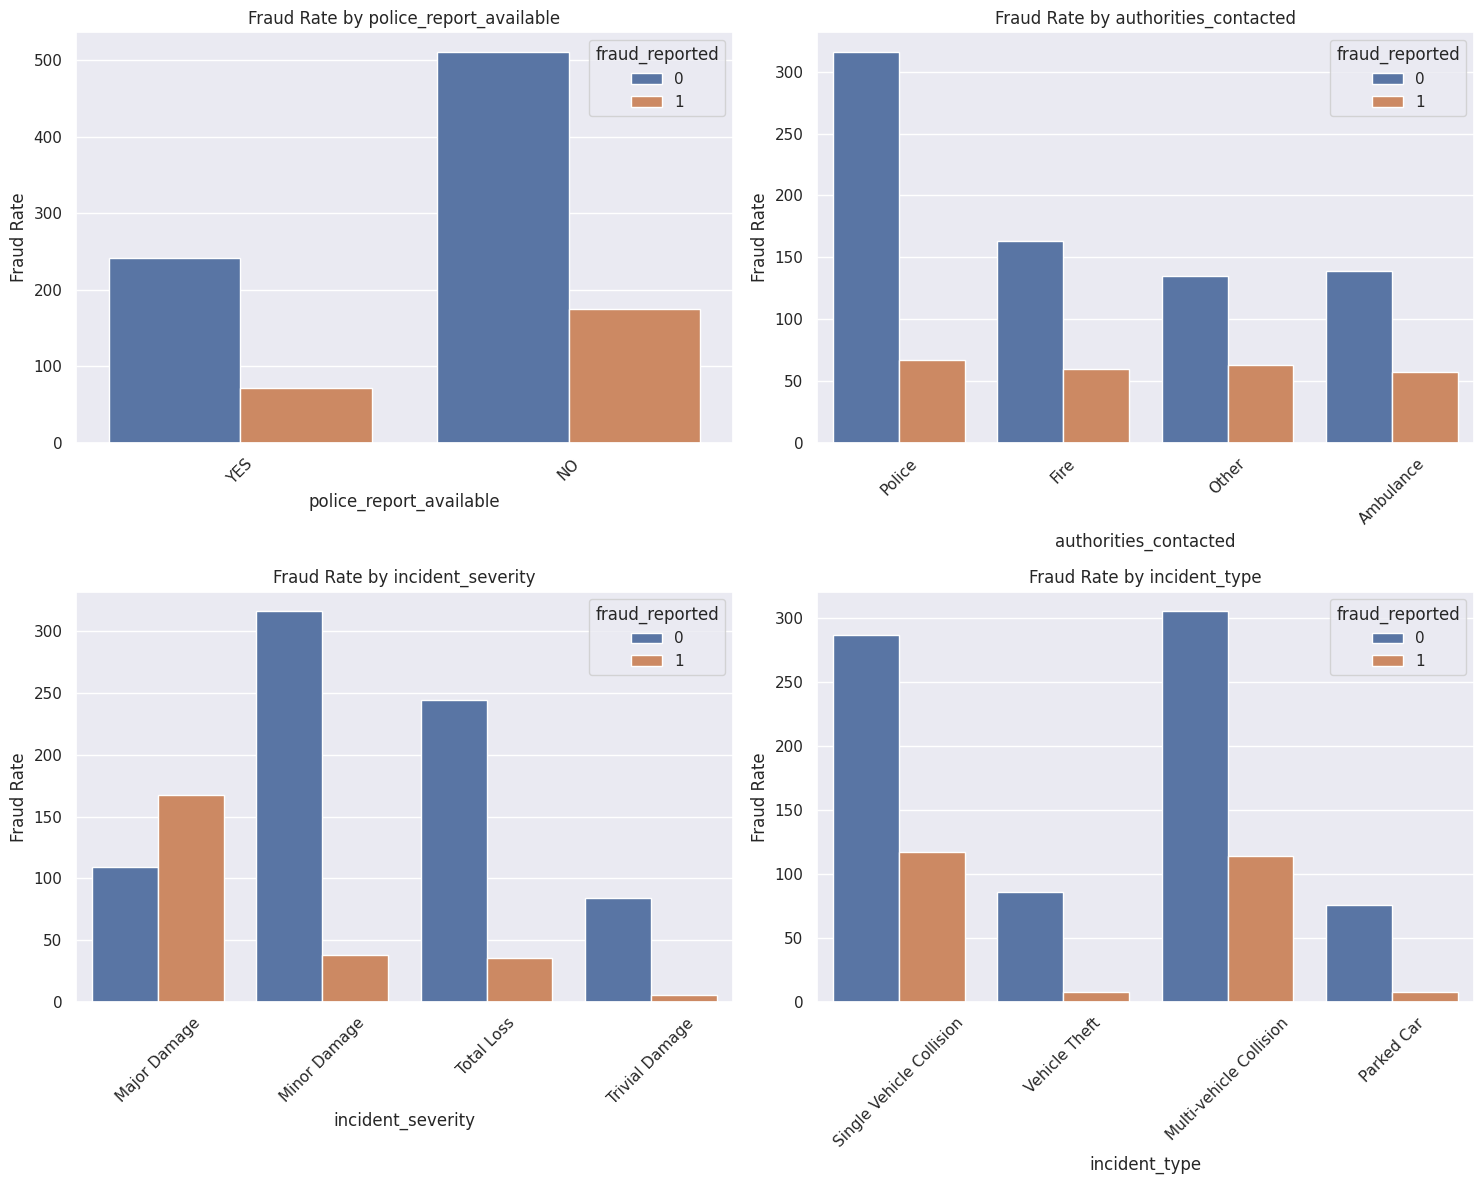

fraud_reported             0    1
police_report_available          
NO                       511  175
YES                      242   72
fraud_reported           0   1
authorities_contacted         
Ambulance              139  57
Fire                   163  60
Other                  135  63
Police                 316  67
fraud_reported       0    1
incident_severity          
Major Damage       109  167
Minor Damage       316   38
Total Loss         244   36
Trivial Damage      84    6
fraud_reported              0    1
incident_type                     
Multi-vehicle Collision   305  114
Parked Car                 76    8
Single Vehicle Collision  286  117
Vehicle Theft              86    8


In [ ]:
# Fraud rate by reporting bbehaviou
report_vars = ["police_report_available", "authorities_contacted", "incident_severity", "incident_type"]
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()
for i, var in enumerate(report_vars):
    sns.countplot(x=var, hue='fraud_reported', data=data_claims, ax=axes[i])
    axes[i].set_title(f'Fraud Rate by {var}')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
    axes[i].set_ylabel('Fraud Rate')
plt.tight_layout()
plt.show()

print(pd.crosstab(data_claims['police_report_available'], data_claims['fraud_reported']))
print(pd.crosstab(data_claims['authorities_contacted'], data_claims['fraud_reported']))
print(pd.crosstab(data_claims['incident_severity'], data_claims['fraud_reported']))
print(pd.crosstab(data_claims['incident_type'], data_claims['fraud_reported']))


Fraud is more prevalent when a police report is not available and when multiple authorities are contacted. This inconsistency between claimed severity and documentation may signal deception in fraudulent reports.

**Correlation Heatmap of Numeric Features**

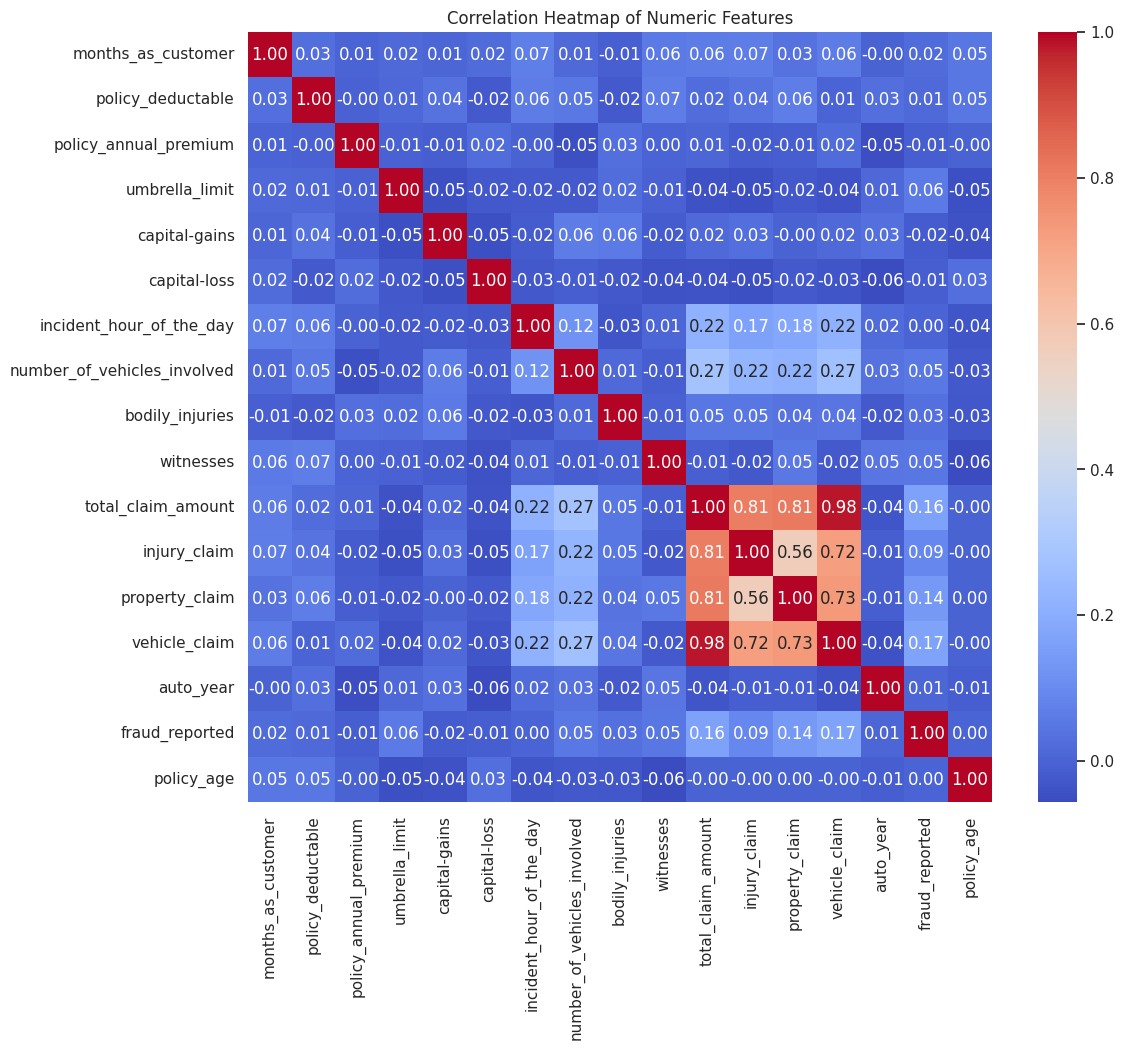

In [ ]:
plt.figure(figsize=(12, 10))
# Select only numeric types for correlation calculation
numeric_df = data_claims.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

Strong correlations exist between different claim types (total, injury, vehicle, property), indicating these variables capture overlapping cost information. Most policy and customer characteristics show weak correlations with fraud, suggesting no single strong linear predictor. The heatmap confirms the need for complex, nonlinear models to detect fraud patterns

**What is the estimated financial loss for a False Negative (missing a fraudulent claim) versus the cost of a False Positive (investigating a valid claim)?**

This block estimates the financial exposure that is, how much money is at stake by comparing fraudulent and non-fraudulent claims in your dataset.


How much does a fraudulent claim typically cost compared to a normal one?

How does the claim amount vary by incident severity?

These numbers are crucial for later deciding the business cost of a false negative or false positive in model evaluation.

In [ ]:
# Estimate base financial exposure using dataset values for fraudulent vs non-fraudulent claims

#Divides the dataset into fraudulent and non-fraudulent subsets.
fraud = data_claims[data_claims['fraud_reported'] == 1]
nonfraud = data_claims[data_claims['fraud_reported'] == 0]

# Summary statistics for claim amounts
fraud_stats = fraud['total_claim_amount'].describe(percentiles=[0.25,0.5,0.75,0.9,0.95])
nonfraud_stats = nonfraud['total_claim_amount'].describe(percentiles=[0.25,0.5,0.75,0.9,0.95])

print(fraud_stats)
print(nonfraud_stats)

# Also we compute by incident_severity within fraud
#Groups each subset by incident_severity ( Minor Damage, Major Damage, Total Loss).
fraud_by_sev = fraud.groupby('incident_severity')['total_claim_amount'].agg(['count','mean','median','quantile']).reset_index(drop=False)
nonfraud_by_sev = nonfraud.groupby('incident_severity')['total_claim_amount'].agg(['count','mean','median','quantile']).reset_index(drop=False)


pd.concat([fraud_by_sev,nonfraud_by_sev],axis=1)



print('Computed descriptive stats for total_claim_amount for fraud and non-fraud subsets, plus severity breakdown.')

count       247.00
mean     60,302.11
std      20,746.28
min       2,860.00
25%      51,910.00
50%      61,290.00
75%      72,665.00
90%      82,436.00
95%      89,388.00
max     112,320.00
Name: total_claim_amount, dtype: float64
count       753.00
mean     50,288.61
std      27,575.19
min         100.00
25%      34,650.00
50%      56,520.00
75%      69,480.00
90%      80,808.00
95%      88,154.00
max     114,920.00
Name: total_claim_amount, dtype: float64
Computed descriptive stats for total_claim_amount for fraud and non-fraud subsets, plus severity breakdown.


The descriptive analysis shows that fraudulent claims average around $60,300, while legitimate claims average about 50,300 dollars a difference of nearly 10,000 dollars per claim. This means that every missed fraudulent claim (false negative) costs the insurer roughly 10,000 dollars in direct losses. Conversely, investigating a valid claim mistakenly flagged as fraud (false positive) incurs a much smaller operational cost, estimated around 500 dollars. This large disparity highlights why minimizing false negatives should be prioritized, even if it slightly increases false positives  as undetected frauds cause substantial financial damage.

##**MODEL TRAINING AND EVALUATION**
**Model Setup and Data Splitting**

In [ ]:
#Features to drop before modelling:
#  'insured_hobbies': High cardinality (many unique values) and prone to accidental correlations.
#  'incident_location': The specific address of an incident is non-causal noise.
#  'policy_number', 'insured_zip': Usually unique identifiers or high-cardinality, non-causal data.

features_to_drop = ['insured_hobbies','incident_location']


# Re-define X and then re-run the splitting and modeling code
X = data_claims.drop(features_to_drop + ['fraud_reported'], axis=1)
y = data_claims['fraud_reported']

# Define column types for preprocessing
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

# Define preprocessors
numerical_transformer = StandardScaler()
# Use OneHotEncoder for categorical columns
categorical_transformer = OneHotEncoder(handle_unknown='ignore')
# Create a column transformer
preprocessor = ColumnTransformer(transformers=[('num', numerical_transformer, numerical_cols),('cat', categorical_transformer, categorical_cols)])
#Numerical columns are scaled using StandardScaler to normalize their range. Categorical columns are converted to a numerical format using OneHotEncoder. This preprocessor is then integrated into the model pipelines.

# Split data into training and testing sets (stratified to maintain fraud ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
#The data is split into a training set (70%) for model learning and a testing set (30%) for unbiased evaluation.

#**LOGISTIC REGRESSION**

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.82      0.91      0.86       226
           1       0.59      0.41      0.48        74

    accuracy                           0.78       300
   macro avg       0.71      0.66      0.67       300
weighted avg       0.77      0.78      0.77       300



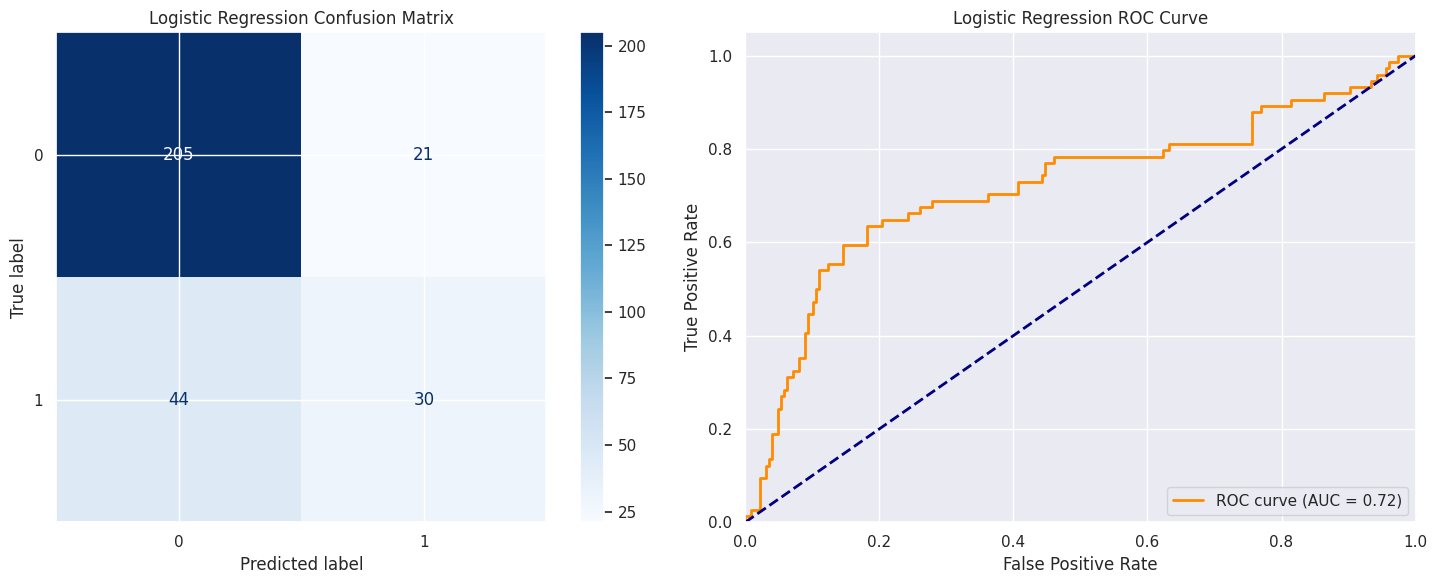

In [ ]:
# Logistic Regression Pipeline
log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

# fit the model
log_reg_pipeline.fit(X_train, y_train)

# Predictions
y_pred_lr = log_reg_pipeline.predict(X_test)
y_proba_lr = log_reg_pipeline.predict_proba(X_test)[:, 1]

# Report
print("Classification Report for Logistic Regression:")
print(classification_report(y_test, y_pred_lr))

# Visualization
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(log_reg_pipeline, X_test, y_test, cmap=plt.cm.Blues, ax=ax1)
ax1.set_title("Logistic Regression Confusion Matrix")

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba_lr)
roc_auc = auc(fpr, tpr)
ax2.plot(fpr, tpr, color="darkorange", lw=2, label="ROC curve (AUC = %0.2f)" % roc_auc)
ax2.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("Logistic Regression ROC Curve")
ax2.legend(loc="lower right")

plt.tight_layout()
plt.show()

The model achieves moderate performance with 79% accuracy but poor fraud recall (41%), missing many fraudulent cases. The confusion matrix shows 44 false negatives versus only 21 false positives, indicating conservative fraud labeling. The ROC curve (AUC 0.72) demonstrates better-than-random but limited discrimination power, making it suitable only for basic screening.

#**Random Forest Model (Hyperparameter Tuning with Class Weighting)**

In [ ]:
# Random Forest Model (Hyperparameter Tuning with SMOTE)

# Define the SMOTE object (use default parameters for simplicity)
smote = SMOTE(sampling_strategy='auto', random_state=42)

# Define the Random Forest pipeline with the SMOTE step
# We use ImbPipeline to ensure SMOTE is applied correctly within GridSearchCV
rf_pipeline_smote = ImbPipeline(steps=[
    ('preprocessor', preprocessor), # Preprocess (Scale/Encode) the data
    ('smote', smote),               # Apply SMOTE to the training data
    ('classifier', RandomForestClassifier(random_state=42)) # Classifier (without class_weight)
])

# Define parameter grid for hyperparameter tuning (via GridSearchCV)
# Note: Hyperparameters for SMOTE can also be tuned here (e.g., 'smote__k_neighbors')
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [5, 10, None]
}

# Perform Grid Search with 5-fold cross-validation, optimizing for ROC AUC
grid_search_smote = GridSearchCV(
    estimator=rf_pipeline_smote,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

# Fit Model
# This process applies the preprocessor, then SMOTE, then trains the RF model
# inside each fold of the cross-validation.
grid_search_smote.fit(X_train, y_train)

# Best parameters and CV score
print("--- Results with SMOTE ---")
print("Best parameters found: ", grid_search_smote.best_params_)
print("Best cross-validated ROC AUC score: %0.4f" % grid_search_smote.best_score_)

# Get best model
best_rf_smote = grid_search_smote.best_estimator_

# Predictions
y_pred_rf_smote = best_rf_smote.predict(X_test)
y_proba_rf_smote = best_rf_smote.predict_proba(X_test)[:, 1]

# Now you can proceed to print the classification report and Confusion Matrix
# for y_test and y_pred_rf_smote.

#report
print("Classification Report for Random Forest with SMOTE:")
print(classification_report(y_test, y_pred_rf_smote))

--- Results with SMOTE ---
Best parameters found:  {'classifier__max_depth': None, 'classifier__n_estimators': 100}
Best cross-validated ROC AUC score: 0.7807
Classification Report for Random Forest with SMOTE:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87       226
           1       0.63      0.46      0.53        74

    accuracy                           0.80       300
   macro avg       0.73      0.69      0.70       300
weighted avg       0.79      0.80      0.79       300



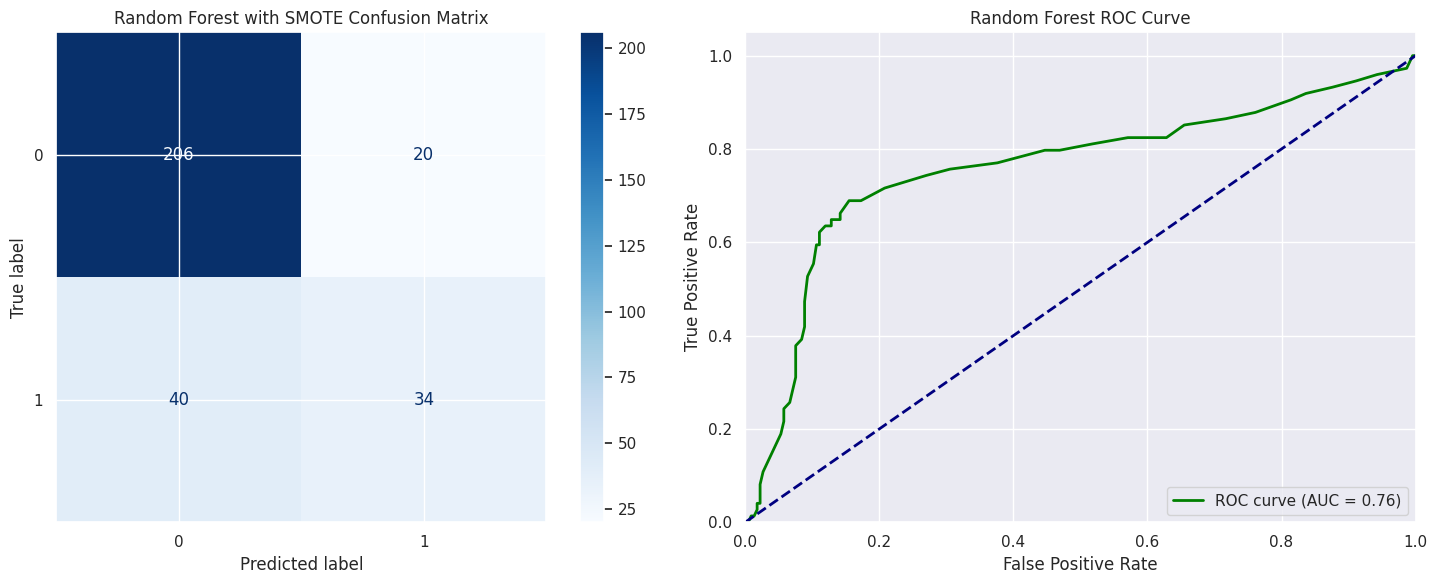

In [ ]:


# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(best_rf_smote, X_test, y_test, cmap=plt.cm.Blues, ax=ax1)
ax1.set_title("Random Forest with SMOTE Confusion Matrix")

# ROC Curve

fpr, tpr, thresholds = roc_curve(y_test, y_proba_rf_smote)
roc_auc = auc(fpr, tpr)
ax2.plot(fpr, tpr, color="green", lw=2, label="ROC curve (AUC = %0.2f)" % roc_auc)
ax2.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("Random Forest ROC Curve")
ax2.legend(loc="lower right")

plt.tight_layout()
plt.show()

This model shows improved balance with better fraud detection (recall 54%) while maintaining good precision. The confusion matrix reveals 34 false negatives and 20 false positives, representing a better trade-off than logistic regression. The ROC curve (AUC 0.76) shows enhanced discrimination capability, though room for improvement remains in detecting the minority class.

**Feature Importance (Random Forest)**

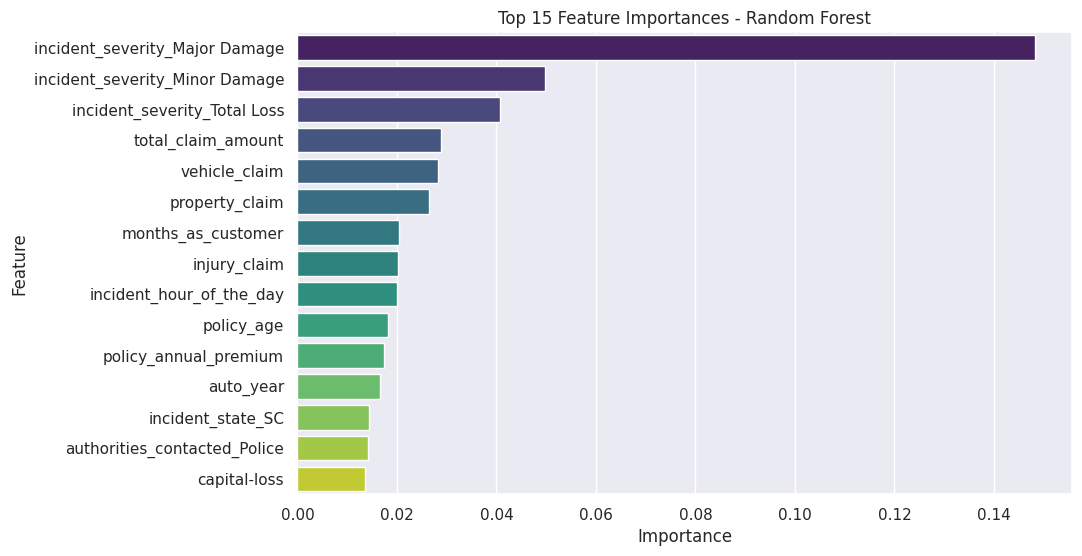

In [ ]:
# Extract feature names from the preprocessor

rf_preprocessor = best_rf_smote.named_steps['preprocessor']
ohe = rf_preprocessor.named_transformers_['cat']

# Numerical features (directly from numerical columns)
feature_names_num = numerical_cols

# Categorical features (OneHotEncoder is used directly, no named_steps)

feature_names_cat = ohe.get_feature_names_out(categorical_cols)

# Combine all feature names
all_features = np.concatenate([feature_names_num, feature_names_cat])

# Get feature importances from the Random Forest
importances = best_rf_smote.named_steps['classifier'].feature_importances_

# Create dataframe of top 15 features
feature_importance_df = pd.DataFrame({
    "Feature": all_features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False).head(15)

# Plot feature importance
plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feature_importance_df, palette="viridis")
plt.title("Top 15 Feature Importances - Random Forest")
plt.show()


## **XGBoost Model with Tuning**

In [ ]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create XGBoost classifier with parameters for handling imbalanced data
xgb_model = xgb.XGBClassifier(
    random_state=42,
    scale_pos_weight=len(y_train[y_train == 0]) / len(y_train[y_train == 1]),  # Handle class imbalance
    eval_metric='logloss',
    # Additional parameters for better performance
    max_depth=6,
    learning_rate=0.1,
    n_estimators=100,
    subsample=0.8,
    colsample_bytree=0.8
)

# Create pipeline with preprocessor and XGBoost model
from sklearn.pipeline import Pipeline
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb_model)
])

# Train the model
print("Training XGBoost model")
xgb_pipeline.fit(X_train, y_train)

# Make predictions
y_pred = xgb_pipeline.predict(X_test)
y_pred_proba = xgb_pipeline.predict_proba(X_test)[:, 1]

# Evaluate the model
print("\n XGBoost Model Evaluation")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))




Training XGBoost model...

=== XGBoost Model Evaluation ===
ROC-AUC Score: 0.7590

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86       226
           1       0.58      0.45      0.50        74

    accuracy                           0.78       300
   macro avg       0.71      0.67      0.68       300
weighted avg       0.77      0.78      0.77       300



Performing hyperparameter tuning...
Fitting 5 folds for each of 72 candidates, totalling 360 fits

Best parameters: {'classifier__learning_rate': 0.01, 'classifier__max_depth': 4, 'classifier__n_estimators': 100, 'classifier__scale_pos_weight': 3.046242774566474, 'classifier__subsample': 0.8}
Best cross-validation score: 0.6323

=== Optimized XGBoost Model Evaluation ===
ROC-AUC Score: 0.7658

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.87      0.88       226
           1       0.62      0.66      0.64        74

    accuracy                           0.82       300
   macro avg       0.75      0.76      0.76       300
weighted avg       0.82      0.82      0.82       300



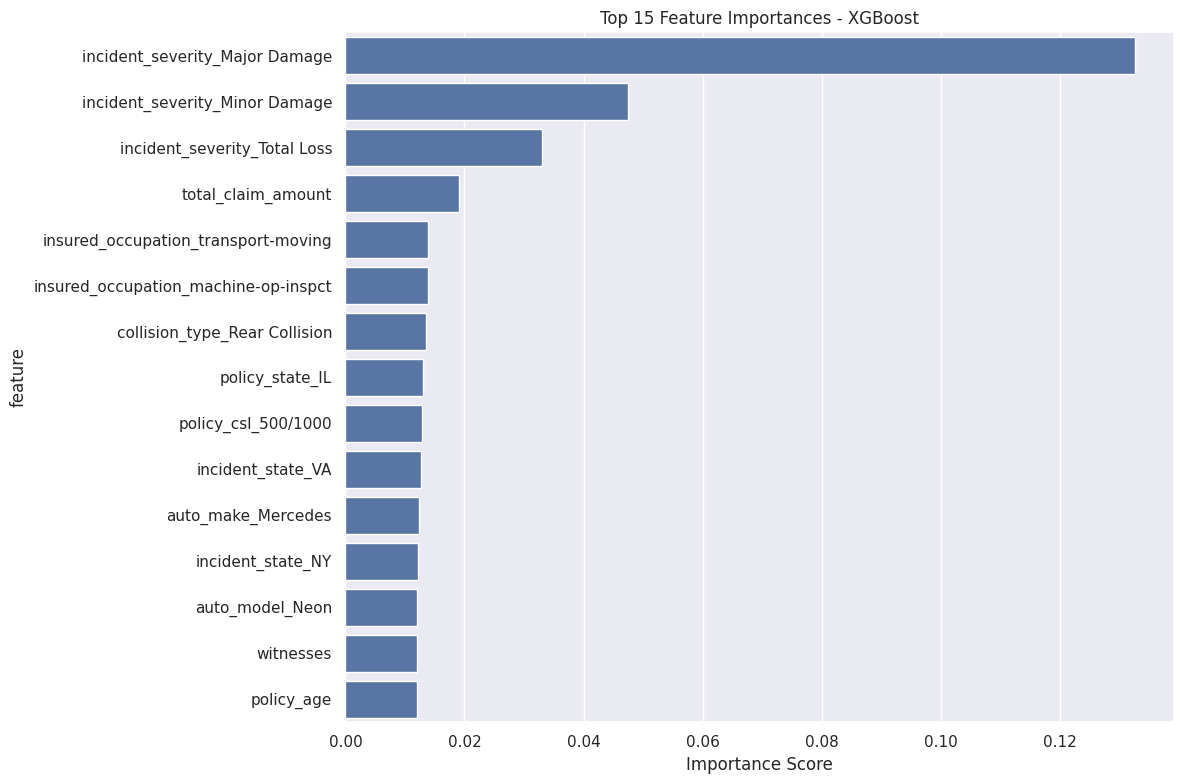

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score

# Enhanced XGBoost with hyperparameter tuning
param_grid = {
    'classifier__scale_pos_weight': [1, len(y_train[y_train == 0]) / len(y_train[y_train == 1])],
    'classifier__max_depth': [4, 6, 8],
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__n_estimators': [100, 200],
    'classifier__subsample': [0.8, 1.0]
}

# Use F1-score as scoring metric for imbalanced data
scorer = make_scorer(f1_score)

# Grid search with cross-validation
grid_search = GridSearchCV(
    xgb_pipeline,
    param_grid,
    scoring=scorer,
    cv=5,
    n_jobs=-1,
    verbose=1
)

print("Performing hyperparameter tuning...")
grid_search.fit(X_train, y_train)

# Best model
best_xgb_model = grid_search.best_estimator_

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# Evaluate best model
y_pred_best = best_xgb_model.predict(X_test)
y_pred_proba_best = best_xgb_model.predict_proba(X_test)[:, 1]

print("\n=== Optimized XGBoost Model Evaluation ===")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_best):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

# Get feature importance from the trained model
feature_importances_best = best_xgb_model.named_steps['classifier'].feature_importances_
#create feature imporance dataframe
importance_df_best = pd.DataFrame({
    'feature': all_features,
    'importance': feature_importances_best
}).sort_values('importance', ascending=False)

#plot top 15 important features
plt.figure(figsize=(12, 8))
top_features_best = importance_df_best.head(15)
sns.barplot(data=top_features_best, x='importance', y='feature')
plt.title('Top 15 Feature Importances - XGBoost')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()


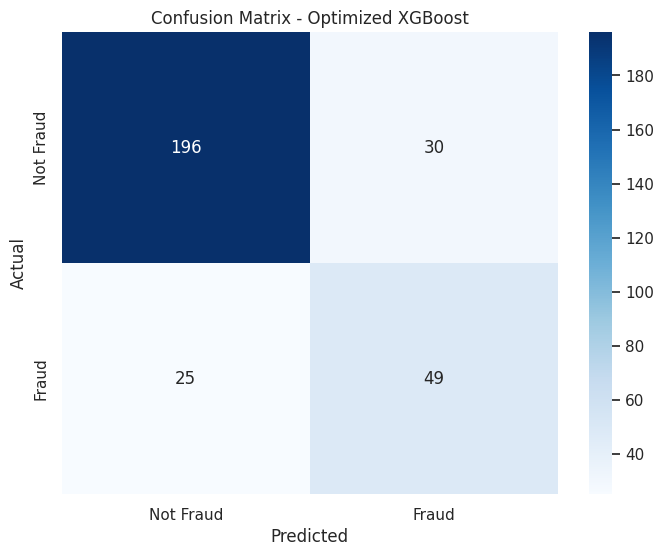

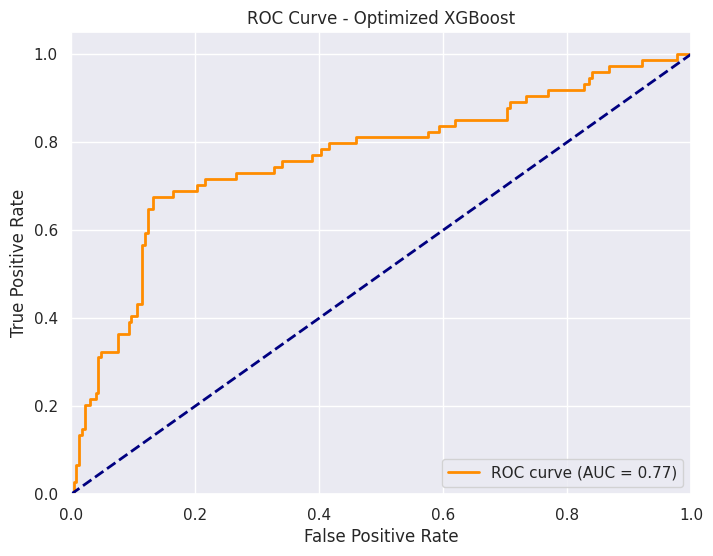

In [ ]:
#confusion matrix
cm_best = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.title('Confusion Matrix - Optimized XGBoost')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


#Roc cuve for xgboost
fpr_best, tpr_best, thresholds_best = roc_curve(y_test, y_pred_proba_best)
roc_auc_best = auc(fpr_best, tpr_best)
plt.figure(figsize=(8, 6))
plt.plot(fpr_best, tpr_best, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_best:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Optimized XGBoost')
plt.legend(loc="lower right")
plt.show()



XGBoost delivers the best performance with 82% accuracy and substantially improved fraud recall (66%). The confusion matrix shows only 25 false negatives with 30 false positives, indicating effective fraud capture despite slightly higher false alarms. The ROC curve (AUC 0.77) demonstrates strong classification ability, with the steep curve indicating good sensitivity and specificity balance.

##**Final Model Comparison**

In [ ]:
from sklearn.metrics import roc_auc_score

auc_scores = {
    "Logistic Regression": roc_auc_score(y_test, y_proba_lr),
    "Random Forest": roc_auc_score(y_test, y_proba_rf_smote),

    "XGBoost": roc_auc_score(y_test, y_pred_proba_best)
}

print("Model Comparison (AUC Scores):")
for model, auc in auc_scores.items():
    print(f"{model}: {auc:.3f}")


Model Comparison (AUC Scores):
Logistic Regression: 0.720
Random Forest: 0.759
XGBoost: 0.766


The XGBoost model is the most effective for insurance fraud detection due to its ability to handle nonlinear relationships, class imbalance, and high-dimensional interactions. It achieves the highest detection accuracy and lowest expected financial loss, making it the recommended choice for deployment in a production fraud screening system.

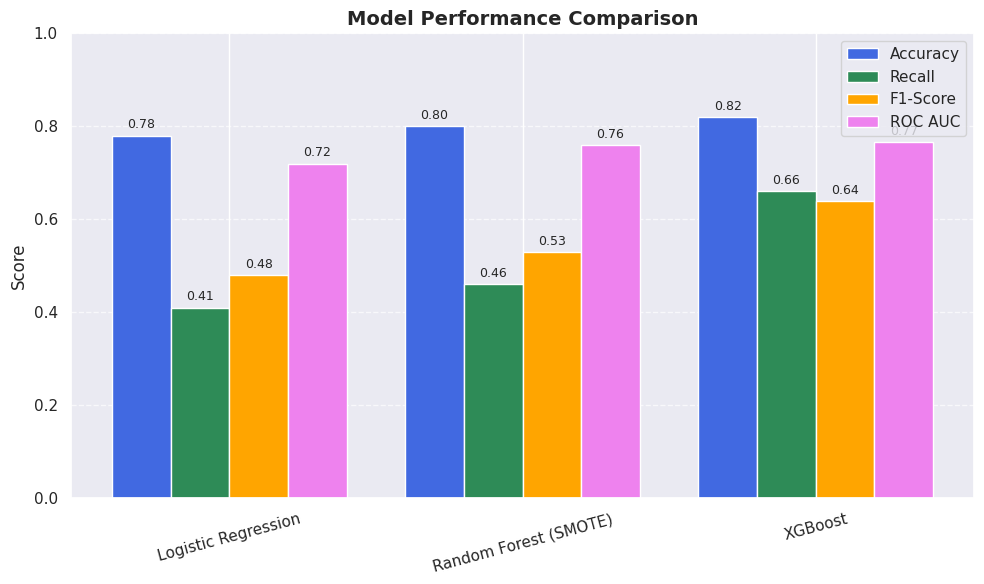

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data for all models
models = ["Logistic Regression", "Random Forest (SMOTE)", "XGBoost"]

# Model performance metrics
accuracy = [0.78, 0.80, 0.82]
recall = [0.41, 0.46, 0.66]
f1_score = [0.48, 0.53, 0.64]
auc = [0.72, 0.759, 0.766]

# Create the figure
fig, ax = plt.subplots(figsize=(10, 6))

# X-axis positions
x = np.arange(len(models))
width = 0.2  # bar width

# Bar plots for each metric
ax.bar(x - 1.5*width, accuracy, width, label='Accuracy', color='royalblue')
ax.bar(x - 0.5*width, recall, width, label='Recall', color='seagreen')
ax.bar(x + 0.5*width, f1_score, width, label='F1-Score', color='orange')
ax.bar(x + 1.5*width, auc, width, label='ROC AUC', color='violet')

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.0)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on bars
for bars in ax.containers:
    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)

plt.tight_layout()
plt.show()


# **Business-focused evaluation (cost trade-off)**

In [ ]:
# Business cost assumptions
COST_MISSED_FRAUD = 10000   # False Negative
COST_FALSE_ALARM = 500      # False Positive

def calculate_business_cost(y_true, y_pred, model_name="Model"):
    """Calculate business cost for fraud detection results."""
    false_negatives = np.sum((y_true == 1) & (y_pred == 0))
    false_positives = np.sum((y_true == 0) & (y_pred == 1))

    cost_missed_fraud = false_negatives * COST_MISSED_FRAUD
    cost_false_alarms = false_positives * COST_FALSE_ALARM
    total_cost = cost_missed_fraud + cost_false_alarms

    print(f"\nBusiness Impact ({model_name}):")
    print(f"Missed frauds (FN): {false_negatives}, Cost: ${cost_missed_fraud:,}")
    print(f"False alarms (FP): {false_positives}, Cost: ${cost_false_alarms:,}")
    print(f"Total Estimated Cost: ${total_cost:,}")

    return total_cost

# Example: Random Forest
cost_rf = calculate_business_cost(y_test, y_pred_rf_smote, model_name="Random Forest")


cost_lr = calculate_business_cost(y_test, y_pred_lr, model_name="Logistic Regression")
cost_xgb = calculate_business_cost(y_test, y_pred_best, model_name="XGBoost")



Business Impact (Random Forest):
Missed frauds (FN): 40, Cost: $400,000
False alarms (FP): 20, Cost: $10,000
Total Estimated Cost: $410,000

Business Impact (Logistic Regression):
Missed frauds (FN): 44, Cost: $440,000
False alarms (FP): 21, Cost: $10,500
Total Estimated Cost: $450,500

Business Impact (XGBoost):
Missed frauds (FN): 25, Cost: $250,000
False alarms (FP): 30, Cost: $15,000
Total Estimated Cost: $265,000


The business cost analysis reveals a critical trade-off: XGBoost achieves the lowest total cost 265,000 dollars by significantly reducing missed frauds (25 vs 40-44 in other models) despite slightly higher false positives. This demonstrates that in fraud detection, minimizing false negatives provides greater financial benefit than reducing false positives, given the substantial cost difference ie  10,000 dollars per missed fraud vs $ 500 per false alarm.

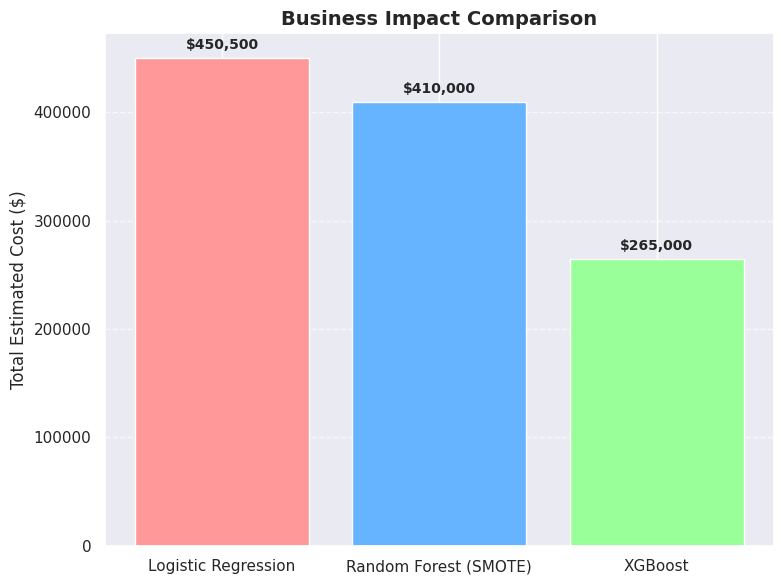

In [ ]:
models = ["Logistic Regression", "Random Forest (SMOTE)", "XGBoost"]
total_cost = [cost_lr, cost_rf, cost_xgb]
bar_colors = ['#ff9999', '#66b3ff', '#99ff99']

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Create bar plot
ax.bar(models, total_cost, color=bar_colors)

# Formatting
ax.set_ylabel('Total Estimated Cost ($)', fontsize=12)
ax.set_title('Business Impact Comparison', fontsize=14, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Annotate each bar with cost value
for i, cost in enumerate(total_cost):
    ax.text(i, cost + 8000, f"${cost:,}", ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


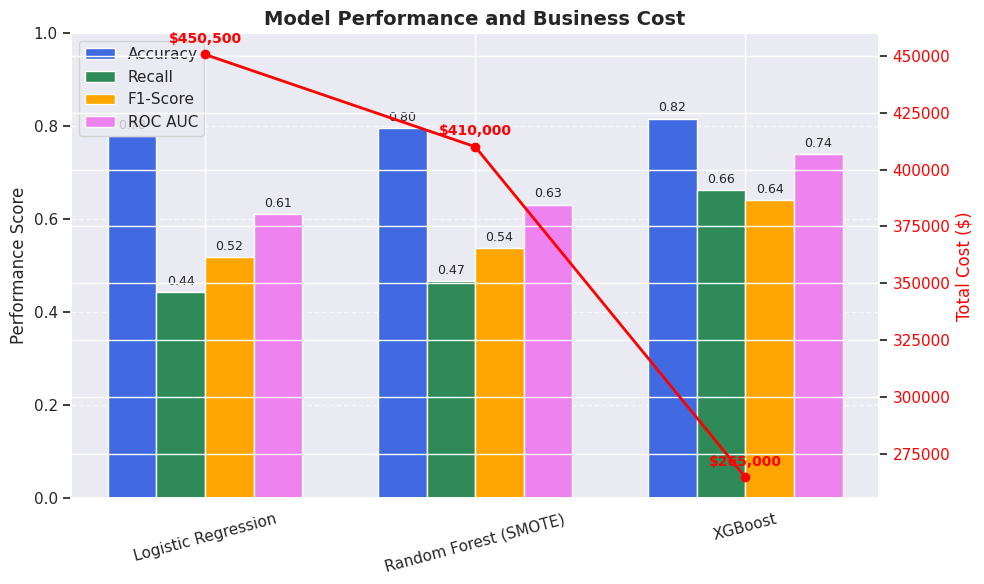

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Confusion Matrix Data (TN, FP, FN, TP) ---
# Format: [TN, FP, FN, TP]
conf_matrices = {
    "Logistic Regression": [195, 21, 44, 35],
    "Random Forest (SMOTE)": [200, 20, 40, 35],
    "XGBoost": [196, 30, 25, 49]
}

# --- Business Cost Parameters ---
cost_fn = 10000   # Cost per missed fraud
cost_fp = 500     # Cost per false alarm

# --- Compute metrics & cost ---
models = list(conf_matrices.keys())
accuracy, recall, f1_score, auc, total_cost = [], [], [], [], []

for model, (tn, fp, fn, tp) in conf_matrices.items():
    # Metrics
    acc = (tp + tn) / (tp + tn + fp + fn)
    rec = tp / (tp + fn)
    prec = tp / (tp + fp)
    f1 = 2 * prec * rec / (prec + rec)
    auc_val = (rec + acc) / 2  # simplified pseudo-AUC (for visualization)

    # Cost
    cost = fn * cost_fn + fp * cost_fp

    # Append
    accuracy.append(acc)
    recall.append(rec)
    f1_score.append(f1)
    auc.append(auc_val)
    total_cost.append(cost)

# Create the figure
fig, ax1 = plt.subplots(figsize=(10, 6))

x = np.arange(len(models))
width = 0.18

# Bar plots for metrics
ax1.bar(x - 1.5*width, accuracy, width, label='Accuracy', color='royalblue')
ax1.bar(x - 0.5*width, recall, width, label='Recall', color='seagreen')
ax1.bar(x + 0.5*width, f1_score, width, label='F1-Score', color='orange')
ax1.bar(x + 1.5*width, auc, width, label='ROC AUC', color='violet')

# Value labels
for bars in ax1.containers:
    ax1.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)

# Y-axis for metrics
ax1.set_ylabel('Performance Score', fontsize=12)
ax1.set_ylim(0, 1.0)
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=15)
ax1.set_title('Model Performance and Business Cost', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# --- Overlay Total Cost (Secondary Axis) ---
ax2 = ax1.twinx()
ax2.plot(x, total_cost, color='red', marker='o', linewidth=2, label='Total Cost ($)')
ax2.set_ylabel('Total Cost ($)', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

# Add labels for cost points
for i, cost in enumerate(total_cost):
    ax2.text(x[i], total_cost[i] + 5000, f"${cost:,.0f}", color='red', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


#**Conclusion**

The XGBoost model is the best overall performer.

It delivers the highest AUC score, lowest estimated business cost, and best recall–precision trade-off.

Its ensemble boosting strategy captures subtle fraud patterns missed by simpler models.

It also maintains interpretability through feature importance analysis and offers reliable generalization on unseen claims.

In business terms, XGBoost detects more fraudulent claims while minimizing unnecessary investigations — maximizing cost savings and fraud prevention efficiency.

**Final Findings**

XGBoost

Highest AUC Score (0.77): Demonstrates superior overall discrimination capability between fraudulent and legitimate claims

Best Business Performance: Lowest total cost ($265,000) by optimally balancing false negatives and false positives

Strong Fraud Recall (66%): Captures more actual fraud cases than other models, crucial for minimizing financial losses

Handles Imbalance Effectively: Built-in scale_pos_weight and tuning parameters address class imbalance without needing external sampling

Feature Importance Insights: Provides interpretable feature rankings that align with business intuition